# **DACOE 2025 Summer Event**

## **Dacoe's Problem Statement**

As part of the DACOE Summer Event on 9th July, we will be hosting the DACOE Challenge!

This year we have continued the artistic theme with a focus on music. Our dataset looks at the history of the UK charts. This is a chance to show us that you know your Taylor Swift from your Cliff Richard (and which one is statistically better?).

The challenge allows you to stretch your engineering and visualisation muscles outside of the confines of the data that you work with on a day-to-day basis.

We welcome entries from teams of DACOE members, as well as individuals. We encourage you to collaborate and learn new skills and techniques that you can take back into your daily work and future careers in data and analytics.


### **Data Engineering**

**The Challenge**

Access the Dataset A - Engineering dataset which contains the data in its rawest form.

Your challenge is to manipulate the data into a useable format for further analysis. This might involve processing into a single dataset or standardising dates and other fields. You are also welcome to amalgamate the data with other relevant information that you can find, perhaps using Artificial Intelligence techniques.

## **Solution**

In order to prepare the data to be in a useable format, the following steps will be undertaken

1. **Data Cleaning**
2. **Feature Engineering**
3. **Enrich data with more features from external sources**
   
    - Build a simple music recommender model
  
4. **Store processed data - Tabular and Graph format**

    - Use natural language to query the data




---

### **1. Data Cleaning**

#### **Basic Cleaning**
- **Remove duplicates**: Ensure no repeated rows.
- **Handle missing values**: Check for and decide how to handle missing values in any column.
- **Standardize column names**: Make them lowercase and replace spaces with underscores for consistency.

#### **Date Handling**
- Convert `start of week` and `end of week` to `datetime` objects.
- Ensure the `end of week` is exactly 6 days after `start of week`.

#### **Data Type Checks**
- Ensure `position` and `last week position` are integers.
- Handle special cases like "New" or "Re-entry" in `last week position` by converting them to a special flag (Nwe = 0 and RE = 101).

#### **Outlier Detection**
- Check for invalid chart positions (e.g., negative numbers or numbers beyond the chart limit like 100).

---

### **2. Feature Engineering**

Extracting meaningful features from your dataset:

#### **Song Performance Features**
- **Weeks on Chart**: Count how many weeks each song has appeared.
- **Peak Position**: The best position a song has reached.
- **First Week Position**: Useful to see how strong a debut was.
- **Last Week on Chart**: The last date the song appeared.

#### **Trend Features**
- **Position Change**: `last_week_position - position` (positive means improvement).
- **Is New Entry**: Boolean flag if `last_week_position` is missing or marked as "New".
- **Is Re-entry**: Boolean flag if a song reappears after being off the chart (RE).
- **Streaks**: Number of consecutive weeks on the chart.

#### **Artist-Level Features**
- **Total Songs by Artist**: Count of unique songs per artist.
- **Average Peak Position**: Average of peak positions for each artist.
- **Longest Charting Song**: For each artist, which song stayed longest.

### **Temporal Features**
- **Week Number**: Extract week number from the date.
- **Year**: Extract year to analyse trends over time.
- **Season**: Categorise weeks into seasons (Winter, Spring, Summer and Autumn).

---

## **1. Data Preprocessing**

In [1]:
#Importing required libraries
import pandas as pd
import numpy as np
from datetime import datetime
import openpyxl
import re
import os
import hashlib
import time

import warnings
warnings.filterwarnings('ignore')

In [2]:
#Specify file path
file_path = 'data/raw/Dataset A - Engineering.xlsx'
#Read all sheet in the file
music_data = pd.read_excel(file_path, sheet_name = None, engine="openpyxl")

In [3]:
#print all sheet neame in file fon concatenation later
print(music_data.keys())

dict_keys(['Week 19521114', 'Week 19521121', 'Week 19521128', 'Week 19521205', 'Week 19521212', 'Week 19521219', 'Week 19521226', 'Week 19530102', 'Week 19530109', 'Week 19530116', 'Week 19530123', 'Week 19530130', 'Week 19530206', 'Week 19530213', 'Week 19530220', 'Week 19530227', 'Week 19530306', 'Week 19530313', 'Week 19530320', 'Week 19530327', 'Week 19530403', 'Week 19530410', 'Week 19530417', 'Week 19530424', 'Week 19530501', 'Week 19530508', 'Week 19530515', 'Week 19530522', 'Week 19530529', 'Week 19530605', 'Week 19530612', 'Week 19530619', 'Week 19530626', 'Week 19530703', 'Week 19530710', 'Week 19530717', 'Week 19530724', 'Week 19530731', 'Week 19530807', 'Week 19530814', 'Week 19530821', 'Week 19530828', 'Week 19530904', 'Week 19530911', 'Week 19530918', 'Week 19530925', 'Week 19531002', 'Week 19531009', 'Week 19531016', 'Week 19531023', 'Week 19531030', 'Week 19531106', 'Week 19531113', 'Week 19531120', 'Week 19531127', 'Week 19531204', 'Week 19531211', 'Week 19531218', 'We

In [4]:
#convert key to list
sheet_name_list = list(music_data.keys())

#Alternative method to get list of sheet names
#sheet_name_list =pd.ExcelFile(file_path).sheet_names



In [5]:
#number of sheets in the file
print(f'There are {len(sheet_name_list)} sheets in the Excel file')

There are 3725 sheets in the Excel file


In [6]:
#testing list
sheet_name_list[20]

'Week 19530403'

In [7]:
#test to see the data from sheet_name_list[20]
sheet_20 = pd.read_excel(file_path, sheet_name = sheet_name_list[20])
sheet_20

,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week
0,SHE WEARS D FEATHERS,GUY MITCHELL,1,LW:1,1,8,3 April 1953- 9 April 1953
1,BROKEN WINGS,STARGAZERS,2,LW:8,2,7,3 April 1953- 9 April 1953
2,NOW,AL MARTINO,3,LW:5,3,10,3 April 1953- 9 April 1953
3,(HOW MUCH IS) THAT DOGGIE IN THE WINDOW,LITA ROZA,4,LW:3,3,4,3 April 1953- 9 April 1953
4,DON'T LET THE STARS GET IN YOUR EYES,PERRY COMO WITH THE RAMBLERS,5,LW:4,1,12,3 April 1953- 9 April 1953
5,WONDERFUL COPENHAGEN,DANNY KAYE,6,LW:6,6,6,3 April 1953- 9 April 1953
6,OH HAPPY DAY,JOHNSTON BROTHERS,7,LW:New,7,1,3 April 1953- 9 April 1953
7,BECAUSE YOU' MINE,MARIO LANZA,8,LW:7,3,21,3 April 1953- 9 April 1953
8,OUTSIDE OF HEAVEN,EDDIE FISHER,9,LW:2,1,14,3 April 1953- 9 April 1953
9,LITTLE D MONKEY,FRANK CHACKSFIELD'S TUNESMITHS,10,LW:New,10,1,3 April 1953- 9 April 1953


### **Combining all sheets into a single table**

#### **Method 1 - Using Pandas**


In [8]:
#Function to read all tabs in excel sheet, combine all into a single table and save in a csv file

def combine_excel_tabs_to_csv(excel_file_path, csv_file_path):
    """
    Combines all tabs from an Excel file into a single CSV file efficiently.

    This function reads one sheet at a time using openpyxl in read-only mode
    and writes incrementally to a CSV file to minimize memory usage.

    Args:
        excel_file_path (str): The path to the input Excel file.
        csv_file_path (str): The path to the output CSV file.
    """
    try:
        # Get all sheet names using openpyxl in read-only mode
        workbook = openpyxl.load_workbook(excel_file_path, read_only=True)
        sheet_names = workbook.sheetnames
        workbook.close()

        # Remove output file if it already exists
        if os.path.exists(csv_file_path):
            os.remove(csv_file_path)

        # Process each sheet one at a time
        for i, sheet in enumerate(sheet_names):
            df = pd.read_excel(excel_file_path, sheet_name=sheet, engine="openpyxl")
            df['Source_Sheet'] = sheet  # Add sheet name as a column

            # Write to CSV: header only for the first sheet
            df.to_csv(csv_file_path, mode='a', index=False, header=(i == 0))

        print(f"Successfully combined {len(sheet_names)} tabs into '{csv_file_path}'")

    except FileNotFoundError:
        print(f"Error: The file '{excel_file_path}' was not found.")
    except Exception as e:
        print(f"An error occurred: {e}")


In [9]:
# Long wait for it to run

# # Define output file paths
# output_csv_file = "data/combined_raw/combined_data.csv"

# # Run the function
# combine_excel_tabs_to_csv(file_path, output_csv_file)

**Please Note:**

Initial try of using pandas to combine all tab was time consuming taking and inefficient. 

A workflow process was recreated in KNIME Analytics Platform which ran efficiently.


#### **Method 2 - Using Knime Analytics**

### **KNIME Workflow**

![title](images/knimw_workflow.png)

In [10]:
#Lets read the combined csv file
combined_data = pd.read_csv('data/combined_raw/combined_data.csv',encoding='cp1252')
combined_data.head(20)

,Song,Artist,Position,Last Week,Peak,Weeks on Chart,Week
0,HE IN MY HEART,AL MARTINO,1,NaN,1,1,14 November 1952- 20 November 1952
1,YOU BELONG TO ME,JO STAFFORD,2,NaN,2,1,14 November 1952- 20 November 1952
2,SOMEWHE ALONG THE WAY,NAT 'KING' COLE,3,NaN,3,1,14 November 1952- 20 November 1952
3,THE ISLE OF INNISFE,BING CROSBY,4,NaN,4,1,14 November 1952- 20 November 1952
4,FEET UP (PAT HIM ON THE PO-PO),GUY MITCHELL,5,NaN,5,1,14 November 1952- 20 November 1952
5,HALF AS MUCH,ROSEMARY CLOONEY,6,NaN,6,1,14 November 1952- 20 November 1952
6,HIGH NOON (DO NOT FORSAKE ME),FRANKIE LAINE,7,NaN,7,1,14 November 1952- 20 November 1952
7,BLUE TANGO,RAY MARTIN,8,NaN,8,1,14 November 1952- 20 November 1952
8,THE HOMING WALTZ,VERA LYNN,9,NaN,9,1,14 November 1952- 20 November 1952
9,AUF WIEDERSEH'N SWEETHEART,VERA LYNN,10,NaN,10,1,14 November 1952- 20 November 1952


### **A. Data Cleaning**

---

### **Data Cleaning Process**

1. **Standardised Column Names**: All column names should be converted to lowercase with underscores.
2. **Parsed Week Range**:
   - Split the `week` column into `start_of_week` and `end_of_week`.
   - Converted both to proper `datetime` objects.
3. **Cleaned `last_week` Column**:
   - Replaced `"New"` and `"RE"` with `0` and `101`.
   - Converted values to numeric.
4. **Converted Columns to Integers**:
   - `position` and `peak` are now integer types (nullable).
5. **Removed Duplicates**: Ensured no repeated rows.

---

In [11]:
print(f'There are {combined_data.shape[0]} rows before dropping duplicates')

There are 285935 rows before dropping duplicates


In [12]:
#Remove duplcate rows
combined_data  = combined_data.drop_duplicates()
print(f'There are {combined_data.shape[0]} rows after dropping duplicates')

There are 285230 rows after dropping duplicates


In [13]:
# Check for highest chart position
lowest_position = combined_data['Position'].min()
highest_position = combined_data['Position'].max()
print(f"Lowest value in column 'Position ': {lowest_position}")
print(f"Highest value in column 'Position ': {highest_position}")

Lowest value in column 'Position ': 1
Highest value in column 'Position ': 100


In [14]:
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 285230 entries, 0 to 285934
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Song            285230 non-null  object
 1   Artist          285181 non-null  object
 2   Position        285230 non-null  int64 
 3   Last Week       285218 non-null  object
 4   Peak            285230 non-null  int64 
 5   Weeks on Chart  285230 non-null  int64 
 6   Week            285230 non-null  object
dtypes: int64(3), object(4)
memory usage: 17.4+ MB


In [15]:
# Standardize column names
combined_data.columns = combined_data.columns.str.strip().str.lower().str.replace(" ", "_")
combined_data.head()

,song,artist,position,last_week,peak,weeks_on_chart,week
0,HE IN MY HEART,AL MARTINO,1,NaN,1,1,14 November 1952- 20 November 1952
1,YOU BELONG TO ME,JO STAFFORD,2,NaN,2,1,14 November 1952- 20 November 1952
2,SOMEWHE ALONG THE WAY,NAT 'KING' COLE,3,NaN,3,1,14 November 1952- 20 November 1952
3,THE ISLE OF INNISFE,BING CROSBY,4,NaN,4,1,14 November 1952- 20 November 1952
4,FEET UP (PAT HIM ON THE PO-PO),GUY MITCHELL,5,NaN,5,1,14 November 1952- 20 November 1952


In [16]:
# Display initial columns for reference
print("Initial columns:", combined_data.columns.tolist())

Initial columns: ['song', 'artist', 'position', 'last_week', 'peak', 'weeks_on_chart', 'week']


In [17]:
combined_data.artist.unique()

array(['AL MARTINO', 'JO STAFFORD', "NAT 'KING' COLE", ...,
       'TYLA/GUNNA/SKILLIBENG', 'HOZIER/ALLISON RUSSELL', 'ALEK OLSEN'],
      dtype=object)

In [18]:
combined_data.song.unique()

array(['HE IN MY HEART', 'YOU BELONG TO ME', 'SOMEWHE ALONG THE WAY', ...,
       'WILDFLOWER AND BARLEY', 'EMPI NOW', "SOMEDAY I'LL GET IT"],
      dtype=object)

In [19]:
def clean_music_text(text):
    """
    Cleans artist or song name by applying the following transformations:
    - Convert to lowercase
    - Replace '#' with 'number'
    - Replace '/' with 'and'
    - Standardize 'featuring' variations to 'ft.'
    - Remove extra whitespace and punctuation
    """
    if not isinstance(text, str):
        return text
    # Convert to lowercase
    text = text.lower()
    # Replace '#' with 'number'
    text = text.replace('#', 'number')
    # Replace '/' with 'and'
    text = text.replace('/', ' and ')
    # Replace '&' with 'and'
    text = text.replace('&', ' and ')
    # Standardize 'featuring' variations to 'ft.'
    text = re.sub(r'(?i)\b(feat\.?|ft\.?|featuring|feature)\b', 'ft.', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # # Remove leading/trailing punctuation
    # text = re.sub(r'^[^\w]+|[^\w]+$', '', text)

    return text




In [20]:
combined_data['artist'] = combined_data['artist'].apply(clean_music_text)
combined_data['song'] = combined_data['song'].apply(clean_music_text)

In [21]:
combined_data.head(20)

,song,artist,position,last_week,peak,weeks_on_chart,week
0,he in my heart,al martino,1,NaN,1,1,14 November 1952- 20 November 1952
1,you belong to me,jo stafford,2,NaN,2,1,14 November 1952- 20 November 1952
2,somewhe along the way,nat 'king' cole,3,NaN,3,1,14 November 1952- 20 November 1952
3,the isle of innisfe,bing crosby,4,NaN,4,1,14 November 1952- 20 November 1952
4,feet up (pat him on the po-po),guy mitchell,5,NaN,5,1,14 November 1952- 20 November 1952
5,half as much,rosemary clooney,6,NaN,6,1,14 November 1952- 20 November 1952
6,high noon (do not forsake me),frankie laine,7,NaN,7,1,14 November 1952- 20 November 1952
7,blue tango,ray martin,8,NaN,8,1,14 November 1952- 20 November 1952
8,the homing waltz,vera lynn,9,NaN,9,1,14 November 1952- 20 November 1952
9,auf wiederseh'n sweetheart,vera lynn,10,NaN,10,1,14 November 1952- 20 November 1952


In [22]:
def split_artists(df, artist_column='artist'):
    """
    Splits the artist column into main_artist and feature_artist based on common featuring patterns.
    
    Args:
        df (pd.DataFrame): The input DataFrame containing an artist column.
        artist_column (str): The name of the column containing artist names.
    
    Returns:
        pd.DataFrame: The DataFrame with two new columns: main_artist and feature_artist.
    """
    def extract_artists(artist_str):
        if pd.isna(artist_str):
            return pd.Series([None, None])        
        parts = artist_str.split(' ft. ')
        main_artist = parts[0].strip()
        feature_artist = parts[1].strip() if len(parts) > 1 else None
        
        return pd.Series([main_artist, feature_artist])
    
    df[['main_artist', 'feature_artist']] = df[artist_column].apply(extract_artists)
    return df



In [23]:
combined_data = split_artists(combined_data, artist_column='artist')
combined_data.head(20)

,song,artist,position,last_week,peak,weeks_on_chart,week,main_artist,feature_artist
0,he in my heart,al martino,1,NaN,1,1,14 November 1952- 20 November 1952,al martino,None
1,you belong to me,jo stafford,2,NaN,2,1,14 November 1952- 20 November 1952,jo stafford,None
2,somewhe along the way,nat 'king' cole,3,NaN,3,1,14 November 1952- 20 November 1952,nat 'king' cole,None
3,the isle of innisfe,bing crosby,4,NaN,4,1,14 November 1952- 20 November 1952,bing crosby,None
4,feet up (pat him on the po-po),guy mitchell,5,NaN,5,1,14 November 1952- 20 November 1952,guy mitchell,None
5,half as much,rosemary clooney,6,NaN,6,1,14 November 1952- 20 November 1952,rosemary clooney,None
6,high noon (do not forsake me),frankie laine,7,NaN,7,1,14 November 1952- 20 November 1952,frankie laine,None
7,blue tango,ray martin,8,NaN,8,1,14 November 1952- 20 November 1952,ray martin,None
8,the homing waltz,vera lynn,9,NaN,9,1,14 November 1952- 20 November 1952,vera lynn,None
9,auf wiederseh'n sweetheart,vera lynn,10,NaN,10,1,14 November 1952- 20 November 1952,vera lynn,None


In [24]:
def split_song(df, song_column='song'):
    """
    Splits the song column into 'song' and 'feature_artist' based on common featuring patterns.
    Only updates 'feature_artist' if a featured artist is found.
    
    Args:
        df (pd.DataFrame): The input DataFrame containing a song column.
        song_column (str): The name of the column containing song names.
    
    Returns:
        pd.DataFrame: The DataFrame with updated 'song' and 'feature_artist' columns.
    """
    def extract_artists(row):
        song_str = row[song_column]
        # Standardize featuring variations to 'ft.'
        standardized = re.sub(r'(?i)\b(feat\.?|ft\.?|featuring|feature)\b', 'ft.', song_str)
        parts = standardized.split(' ft. ')
        song = parts[0].strip()
        # Only update feature_artist if a featured artist is found
        if len(parts) > 1 and parts[1].strip():
            feature_artist = parts[1].strip()
        else:
            feature_artist = row.get('feature_artist', None)
        return pd.Series([song, feature_artist])    
    df[['song', 'feature_artist']] = df.apply(extract_artists, axis=1)
    return df



In [25]:
combined_data = split_song(combined_data, song_column='song')
combined_data.head(20)

,song,artist,position,last_week,peak,weeks_on_chart,week,main_artist,feature_artist
0,he in my heart,al martino,1,NaN,1,1,14 November 1952- 20 November 1952,al martino,None
1,you belong to me,jo stafford,2,NaN,2,1,14 November 1952- 20 November 1952,jo stafford,None
2,somewhe along the way,nat 'king' cole,3,NaN,3,1,14 November 1952- 20 November 1952,nat 'king' cole,None
3,the isle of innisfe,bing crosby,4,NaN,4,1,14 November 1952- 20 November 1952,bing crosby,None
4,feet up (pat him on the po-po),guy mitchell,5,NaN,5,1,14 November 1952- 20 November 1952,guy mitchell,None
5,half as much,rosemary clooney,6,NaN,6,1,14 November 1952- 20 November 1952,rosemary clooney,None
6,high noon (do not forsake me),frankie laine,7,NaN,7,1,14 November 1952- 20 November 1952,frankie laine,None
7,blue tango,ray martin,8,NaN,8,1,14 November 1952- 20 November 1952,ray martin,None
8,the homing waltz,vera lynn,9,NaN,9,1,14 November 1952- 20 November 1952,vera lynn,None
9,auf wiederseh'n sweetheart,vera lynn,10,NaN,10,1,14 November 1952- 20 November 1952,vera lynn,None


In [26]:
def generate_unique_id(df, main_artist_col='main_artist', song_col='song'):
    """
    Creates a 'unique_id' column by combining 'main_artist' and 'song' columns.
    The result is lowercase, stripped of extra whitespace, and joined with underscores.
    """
    df['unique_id'] = (
        df[main_artist_col].astype(str).str.strip().str.lower().str.replace(r'\s+', '_', regex=True) + '_' +
        df[song_col].astype(str).str.strip().str.lower().str.replace(r'\s+', '_', regex=True)
    )
    # Create unique_no by hashing the unique_id and converting to integer
    df['unique_no'] = df['unique_id'].apply(lambda x: int(hashlib.sha256(x.encode()).hexdigest(), 16) % (10 ** 10))

    return df

In [27]:
# Generate unique identifier using main_artist and song
combined_data = generate_unique_id(combined_data, main_artist_col='main_artist', song_col='song')
combined_data.head(20)

,song,artist,position,last_week,peak,weeks_on_chart,week,main_artist,feature_artist,unique_id,unique_no
0,he in my heart,al martino,1,NaN,1,1,14 November 1952- 20 November 1952,al martino,None,al_martino_he_in_my_heart,5344653606
1,you belong to me,jo stafford,2,NaN,2,1,14 November 1952- 20 November 1952,jo stafford,None,jo_stafford_you_belong_to_me,1353313143
2,somewhe along the way,nat 'king' cole,3,NaN,3,1,14 November 1952- 20 November 1952,nat 'king' cole,None,nat_'king'_cole_somewhe_along_the_way,9285615240
3,the isle of innisfe,bing crosby,4,NaN,4,1,14 November 1952- 20 November 1952,bing crosby,None,bing_crosby_the_isle_of_innisfe,8995184836
4,feet up (pat him on the po-po),guy mitchell,5,NaN,5,1,14 November 1952- 20 November 1952,guy mitchell,None,guy_mitchell_feet_up_(pat_him_on_the_po-po),9991277551
5,half as much,rosemary clooney,6,NaN,6,1,14 November 1952- 20 November 1952,rosemary clooney,None,rosemary_clooney_half_as_much,4244915198
6,high noon (do not forsake me),frankie laine,7,NaN,7,1,14 November 1952- 20 November 1952,frankie laine,None,frankie_laine_high_noon_(do_not_forsake_me),4158082603
7,blue tango,ray martin,8,NaN,8,1,14 November 1952- 20 November 1952,ray martin,None,ray_martin_blue_tango,3839992792
8,the homing waltz,vera lynn,9,NaN,9,1,14 November 1952- 20 November 1952,vera lynn,None,vera_lynn_the_homing_waltz,5134468906
9,auf wiederseh'n sweetheart,vera lynn,10,NaN,10,1,14 November 1952- 20 November 1952,vera lynn,None,vera_lynn_auf_wiederseh'n_sweetheart,2369804095


In [28]:
# Split 'week' column into 'start_of_week' and 'end_of_week'
combined_data[['start_of_week', 'end_of_week']] = combined_data['week'].str.split('-', expand=True)
combined_data['start_of_week'] = pd.to_datetime(combined_data['start_of_week'].str.strip(), errors='coerce')
combined_data['end_of_week'] = pd.to_datetime(combined_data['end_of_week'].str.strip(), errors='coerce')
combined_data.drop(columns=['week'], inplace=True)
combined_data.head(20)

,song,artist,position,last_week,peak,weeks_on_chart,main_artist,feature_artist,unique_id,unique_no,start_of_week,end_of_week
0,he in my heart,al martino,1,NaN,1,1,al martino,None,al_martino_he_in_my_heart,5344653606,1952-11-14,1952-11-20
1,you belong to me,jo stafford,2,NaN,2,1,jo stafford,None,jo_stafford_you_belong_to_me,1353313143,1952-11-14,1952-11-20
2,somewhe along the way,nat 'king' cole,3,NaN,3,1,nat 'king' cole,None,nat_'king'_cole_somewhe_along_the_way,9285615240,1952-11-14,1952-11-20
3,the isle of innisfe,bing crosby,4,NaN,4,1,bing crosby,None,bing_crosby_the_isle_of_innisfe,8995184836,1952-11-14,1952-11-20
4,feet up (pat him on the po-po),guy mitchell,5,NaN,5,1,guy mitchell,None,guy_mitchell_feet_up_(pat_him_on_the_po-po),9991277551,1952-11-14,1952-11-20
5,half as much,rosemary clooney,6,NaN,6,1,rosemary clooney,None,rosemary_clooney_half_as_much,4244915198,1952-11-14,1952-11-20
6,high noon (do not forsake me),frankie laine,7,NaN,7,1,frankie laine,None,frankie_laine_high_noon_(do_not_forsake_me),4158082603,1952-11-14,1952-11-20
7,blue tango,ray martin,8,NaN,8,1,ray martin,None,ray_martin_blue_tango,3839992792,1952-11-14,1952-11-20
8,the homing waltz,vera lynn,9,NaN,9,1,vera lynn,None,vera_lynn_the_homing_waltz,5134468906,1952-11-14,1952-11-20
9,auf wiederseh'n sweetheart,vera lynn,10,NaN,10,1,vera lynn,None,vera_lynn_auf_wiederseh'n_sweetheart,2369804095,1952-11-14,1952-11-20


In [29]:
# Clean 'last_week' column
combined_data[['last_week_prefix', 'last_week_position']] = combined_data['last_week'].str.split(':', expand=True)
combined_data['last_week_position'] = combined_data.last_week_position.fillna('New')
combined_data['last_week'] = combined_data['last_week_position'].replace({'New': 0, 'RE': 101})
combined_data['last_week'] = pd.to_numeric(combined_data['last_week'], errors='coerce')
combined_data.drop(columns=['last_week_prefix', 'last_week_position'], inplace=True)
combined_data.head(20)

,song,artist,position,last_week,peak,weeks_on_chart,main_artist,feature_artist,unique_id,unique_no,start_of_week,end_of_week
0,he in my heart,al martino,1,0,1,1,al martino,None,al_martino_he_in_my_heart,5344653606,1952-11-14,1952-11-20
1,you belong to me,jo stafford,2,0,2,1,jo stafford,None,jo_stafford_you_belong_to_me,1353313143,1952-11-14,1952-11-20
2,somewhe along the way,nat 'king' cole,3,0,3,1,nat 'king' cole,None,nat_'king'_cole_somewhe_along_the_way,9285615240,1952-11-14,1952-11-20
3,the isle of innisfe,bing crosby,4,0,4,1,bing crosby,None,bing_crosby_the_isle_of_innisfe,8995184836,1952-11-14,1952-11-20
4,feet up (pat him on the po-po),guy mitchell,5,0,5,1,guy mitchell,None,guy_mitchell_feet_up_(pat_him_on_the_po-po),9991277551,1952-11-14,1952-11-20
5,half as much,rosemary clooney,6,0,6,1,rosemary clooney,None,rosemary_clooney_half_as_much,4244915198,1952-11-14,1952-11-20
6,high noon (do not forsake me),frankie laine,7,0,7,1,frankie laine,None,frankie_laine_high_noon_(do_not_forsake_me),4158082603,1952-11-14,1952-11-20
7,blue tango,ray martin,8,0,8,1,ray martin,None,ray_martin_blue_tango,3839992792,1952-11-14,1952-11-20
8,the homing waltz,vera lynn,9,0,9,1,vera lynn,None,vera_lynn_the_homing_waltz,5134468906,1952-11-14,1952-11-20
9,auf wiederseh'n sweetheart,vera lynn,10,0,10,1,vera lynn,None,vera_lynn_auf_wiederseh'n_sweetheart,2369804095,1952-11-14,1952-11-20


In [30]:
# Convert position and peak to numeric
combined_data['position'] = pd.to_numeric(combined_data['position'], errors='coerce')
combined_data['peak'] = pd.to_numeric(combined_data['peak'], errors='coerce')
combined_data.head()

,song,artist,position,last_week,peak,weeks_on_chart,main_artist,feature_artist,unique_id,unique_no,start_of_week,end_of_week
0,he in my heart,al martino,1,0,1,1,al martino,None,al_martino_he_in_my_heart,5344653606,1952-11-14,1952-11-20
1,you belong to me,jo stafford,2,0,2,1,jo stafford,None,jo_stafford_you_belong_to_me,1353313143,1952-11-14,1952-11-20
2,somewhe along the way,nat 'king' cole,3,0,3,1,nat 'king' cole,None,nat_'king'_cole_somewhe_along_the_way,9285615240,1952-11-14,1952-11-20
3,the isle of innisfe,bing crosby,4,0,4,1,bing crosby,None,bing_crosby_the_isle_of_innisfe,8995184836,1952-11-14,1952-11-20
4,feet up (pat him on the po-po),guy mitchell,5,0,5,1,guy mitchell,None,guy_mitchell_feet_up_(pat_him_on_the_po-po),9991277551,1952-11-14,1952-11-20


In [31]:
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 285230 entries, 0 to 285934
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   song            285230 non-null  object        
 1   artist          285181 non-null  object        
 2   position        285230 non-null  int64         
 3   last_week       285230 non-null  int64         
 4   peak            285230 non-null  int64         
 5   weeks_on_chart  285230 non-null  int64         
 6   main_artist     285181 non-null  object        
 7   feature_artist  23947 non-null   object        
 8   unique_id       285230 non-null  object        
 9   unique_no       285230 non-null  int64         
 10  start_of_week   285230 non-null  datetime64[ns]
 11  end_of_week     285230 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(5), object(5)
memory usage: 28.3+ MB


In [32]:
combined_data.describe()

,position,last_week,peak,weeks_on_chart,unique_no
count,285230.000000,285230.000000,285230.000000,285230.000000,2.852300e+05
mean,43.901802,33.571672,24.166013,9.089377,4.960750e+09
std,28.071598,29.568978,24.769626,15.287234,2.871409e+09
min,1.000000,0.000000,1.000000,1.000000,6.571800e+04
25%,20.000000,8.000000,4.000000,2.000000,2.465129e+09
50%,41.000000,28.000000,15.000000,5.000000,4.935178e+09
75%,67.000000,52.000000,37.000000,10.000000,7.420293e+09
max,100.000000,101.000000,100.000000,403.000000,9.999766e+09


### **B. Feature Engineering**

---

### **Song-Level Features**
| Feature | Description |
|--------|-------------|
| `weeks_on_chart_total` | Number of weeks the song appeared on the chart (recomputed from data). |
| `peak_position` | Best chart position the song achieved. |
| `first_week_position` | Position of the song in its first week on the chart. |
| `last_week_on_chart` | Last week the song appeared on the chart. |
| `position_change` | Difference between last week's and current position. |
| `is_new_entry` | Whether the song is a new entry this week. |
| `is_reentry` | Whether the song re-entered the chart after being off. |
| `consecutive_weeks_on_chart` | Count of consecutive weeks the song has been on the chart. |

---

### **Artist-Level Features**
| Feature | Description |
|--------|-------------|
| `total_songs_by_artist` | Number of unique songs by the artist in the dataset. |
| `average_peak_position_by_artist` | Average of peak positions across all songs by the artist. |
| `longest_charting_song_by_artist` | The artist’s song with the most weeks on the chart. |

---

### **Temporal Features**
| Feature | Description |
|--------|-------------|
| `week_number` | ISO week number of the year. |
| `month` | Month of the chart week. |
| `year` | Year of the chart week. |
| `season` | Season of the year (Winter, Spring, Summer, Autumn). |

---


In [33]:
# Feature 1: weeks_on_chart per song
weeks_on_chart_total = combined_data.groupby(['song', 'artist']).size().reset_index(name='weeks_on_chart_total')
weeks_on_chart_total.head()

,song,artist,weeks_on_chart_total
0,'74-'75,connells,11
1,'74-'75,hands of belli and nancy edwards,1
2,'80's romance,the belle stars,4
3,'92 tour ep,motorhead,1
4,'cause cheap is how i feel,cowboy junkies,2


In [34]:
# Feature 2: peak_position per song
peak_position_highest = combined_data.groupby(['song', 'artist'])['position'].min().reset_index(name='peak_position')
peak_position_highest.head()

,song,artist,peak_position
0,'74-'75,connells,14
1,'74-'75,hands of belli and nancy edwards,92
2,'80's romance,the belle stars,71
3,'92 tour ep,motorhead,63
4,'cause cheap is how i feel,cowboy junkies,93


In [35]:
# Feature 3: first_week_position
first_week_position = combined_data.sort_values('start_of_week').groupby(['song', 'artist']).first().reset_index()[['song', 'artist', 'position']]
first_week_position.rename(columns={'position': 'first_week_position'}, inplace=True)
first_week_position.head()

,song,artist,first_week_position
0,'74-'75,connells,14
1,'74-'75,hands of belli and nancy edwards,92
2,'80's romance,the belle stars,82
3,'92 tour ep,motorhead,63
4,'cause cheap is how i feel,cowboy junkies,94


In [36]:
# Feature 4: last_week_on_chart
last_week_date_on_chart = combined_data.groupby(['song', 'artist'])['start_of_week'].max().reset_index(name='last_week_date_on_chart')
last_week_date_on_chart.head()

,song,artist,last_week_date_on_chart
0,'74-'75,connells,1996-03-24
1,'74-'75,hands of belli and nancy edwards,1996-02-11
2,'80's romance,the belle stars,1984-07-15
3,'92 tour ep,motorhead,1992-11-08
4,'cause cheap is how i feel,cowboy junkies,1990-07-15


In [37]:
# Merge all song-level features
combined_data = combined_data.merge(weeks_on_chart_total, on=['song', 'artist'], how='left')
combined_data = combined_data.merge(peak_position_highest, on=['song', 'artist'], how='left')
combined_data = combined_data.merge(first_week_position, on=['song', 'artist'], how='left')
combined_data = combined_data.merge(last_week_date_on_chart, on=['song', 'artist'], how='left')
combined_data.head(5)

,song,artist,position,last_week,peak,weeks_on_chart,main_artist,feature_artist,unique_id,unique_no,start_of_week,end_of_week,weeks_on_chart_total,peak_position,first_week_position,last_week_date_on_chart
0,he in my heart,al martino,1,0,1,1,al martino,None,al_martino_he_in_my_heart,5344653606,1952-11-14,1952-11-20,17.0,1.0,1.0,1953-03-06
1,you belong to me,jo stafford,2,0,2,1,jo stafford,None,jo_stafford_you_belong_to_me,1353313143,1952-11-14,1952-11-20,20.0,1.0,2.0,1953-03-13
2,somewhe along the way,nat 'king' cole,3,0,3,1,nat 'king' cole,None,nat_'king'_cole_somewhe_along_the_way,9285615240,1952-11-14,1952-11-20,4.0,3.0,3.0,1952-12-12
3,the isle of innisfe,bing crosby,4,0,4,1,bing crosby,None,bing_crosby_the_isle_of_innisfe,8995184836,1952-11-14,1952-11-20,9.0,4.0,4.0,1953-01-30
4,feet up (pat him on the po-po),guy mitchell,5,0,5,1,guy mitchell,None,guy_mitchell_feet_up_(pat_him_on_the_po-po),9991277551,1952-11-14,1952-11-20,9.0,2.0,5.0,1953-01-09


In [38]:
# Feature 5: position_change from last week
#combined_data['position_change'] = combined_data['last_week'] - combined_data['position']

combined_data['position_change'] = np.where(combined_data['last_week'].isin([0, 101]),0,
                                            combined_data['last_week'] - combined_data['position'])

combined_data.head(20)

,song,artist,position,last_week,peak,weeks_on_chart,main_artist,feature_artist,unique_id,unique_no,start_of_week,end_of_week,weeks_on_chart_total,peak_position,first_week_position,last_week_date_on_chart,position_change
0,he in my heart,al martino,1,0,1,1,al martino,None,al_martino_he_in_my_heart,5344653606,1952-11-14,1952-11-20,17.0,1.0,1.0,1953-03-06,0
1,you belong to me,jo stafford,2,0,2,1,jo stafford,None,jo_stafford_you_belong_to_me,1353313143,1952-11-14,1952-11-20,20.0,1.0,2.0,1953-03-13,0
2,somewhe along the way,nat 'king' cole,3,0,3,1,nat 'king' cole,None,nat_'king'_cole_somewhe_along_the_way,9285615240,1952-11-14,1952-11-20,4.0,3.0,3.0,1952-12-12,0
3,the isle of innisfe,bing crosby,4,0,4,1,bing crosby,None,bing_crosby_the_isle_of_innisfe,8995184836,1952-11-14,1952-11-20,9.0,4.0,4.0,1953-01-30,0
4,feet up (pat him on the po-po),guy mitchell,5,0,5,1,guy mitchell,None,guy_mitchell_feet_up_(pat_him_on_the_po-po),9991277551,1952-11-14,1952-11-20,9.0,2.0,5.0,1953-01-09,0
5,half as much,rosemary clooney,6,0,6,1,rosemary clooney,None,rosemary_clooney_half_as_much,4244915198,1952-11-14,1952-11-20,9.0,3.0,6.0,1953-01-02,0
6,high noon (do not forsake me),frankie laine,7,0,7,1,frankie laine,None,frankie_laine_high_noon_(do_not_forsake_me),4158082603,1952-11-14,1952-11-20,7.0,7.0,7.0,1952-12-26,0
7,blue tango,ray martin,8,0,8,1,ray martin,None,ray_martin_blue_tango,3839992792,1952-11-14,1952-11-20,5.0,8.0,8.0,1952-12-12,0
8,the homing waltz,vera lynn,9,0,9,1,vera lynn,None,vera_lynn_the_homing_waltz,5134468906,1952-11-14,1952-11-20,3.0,9.0,9.0,1952-11-28,0
9,auf wiederseh'n sweetheart,vera lynn,10,0,10,1,vera lynn,None,vera_lynn_auf_wiederseh'n_sweetheart,2369804095,1952-11-14,1952-11-20,1.0,10.0,10.0,1952-11-14,0


In [39]:
# Feature 6: is_new_entry
combined_data['is_new_entry'] = combined_data['last_week'] == 0
combined_data.head(20)

,song,artist,position,last_week,peak,weeks_on_chart,main_artist,feature_artist,unique_id,unique_no,start_of_week,end_of_week,weeks_on_chart_total,peak_position,first_week_position,last_week_date_on_chart,position_change,is_new_entry
0,he in my heart,al martino,1,0,1,1,al martino,None,al_martino_he_in_my_heart,5344653606,1952-11-14,1952-11-20,17.0,1.0,1.0,1953-03-06,0,True
1,you belong to me,jo stafford,2,0,2,1,jo stafford,None,jo_stafford_you_belong_to_me,1353313143,1952-11-14,1952-11-20,20.0,1.0,2.0,1953-03-13,0,True
2,somewhe along the way,nat 'king' cole,3,0,3,1,nat 'king' cole,None,nat_'king'_cole_somewhe_along_the_way,9285615240,1952-11-14,1952-11-20,4.0,3.0,3.0,1952-12-12,0,True
3,the isle of innisfe,bing crosby,4,0,4,1,bing crosby,None,bing_crosby_the_isle_of_innisfe,8995184836,1952-11-14,1952-11-20,9.0,4.0,4.0,1953-01-30,0,True
4,feet up (pat him on the po-po),guy mitchell,5,0,5,1,guy mitchell,None,guy_mitchell_feet_up_(pat_him_on_the_po-po),9991277551,1952-11-14,1952-11-20,9.0,2.0,5.0,1953-01-09,0,True
5,half as much,rosemary clooney,6,0,6,1,rosemary clooney,None,rosemary_clooney_half_as_much,4244915198,1952-11-14,1952-11-20,9.0,3.0,6.0,1953-01-02,0,True
6,high noon (do not forsake me),frankie laine,7,0,7,1,frankie laine,None,frankie_laine_high_noon_(do_not_forsake_me),4158082603,1952-11-14,1952-11-20,7.0,7.0,7.0,1952-12-26,0,True
7,blue tango,ray martin,8,0,8,1,ray martin,None,ray_martin_blue_tango,3839992792,1952-11-14,1952-11-20,5.0,8.0,8.0,1952-12-12,0,True
8,the homing waltz,vera lynn,9,0,9,1,vera lynn,None,vera_lynn_the_homing_waltz,5134468906,1952-11-14,1952-11-20,3.0,9.0,9.0,1952-11-28,0,True
9,auf wiederseh'n sweetheart,vera lynn,10,0,10,1,vera lynn,None,vera_lynn_auf_wiederseh'n_sweetheart,2369804095,1952-11-14,1952-11-20,1.0,10.0,10.0,1952-11-14,0,True


In [40]:
# Feature 7: is_reentry
combined_data['is_reentry'] = combined_data['last_week'] == 101
combined_data.head(20)

,song,artist,position,last_week,peak,weeks_on_chart,main_artist,feature_artist,unique_id,unique_no,start_of_week,end_of_week,weeks_on_chart_total,peak_position,first_week_position,last_week_date_on_chart,position_change,is_new_entry,is_reentry
0,he in my heart,al martino,1,0,1,1,al martino,None,al_martino_he_in_my_heart,5344653606,1952-11-14,1952-11-20,17.0,1.0,1.0,1953-03-06,0,True,False
1,you belong to me,jo stafford,2,0,2,1,jo stafford,None,jo_stafford_you_belong_to_me,1353313143,1952-11-14,1952-11-20,20.0,1.0,2.0,1953-03-13,0,True,False
2,somewhe along the way,nat 'king' cole,3,0,3,1,nat 'king' cole,None,nat_'king'_cole_somewhe_along_the_way,9285615240,1952-11-14,1952-11-20,4.0,3.0,3.0,1952-12-12,0,True,False
3,the isle of innisfe,bing crosby,4,0,4,1,bing crosby,None,bing_crosby_the_isle_of_innisfe,8995184836,1952-11-14,1952-11-20,9.0,4.0,4.0,1953-01-30,0,True,False
4,feet up (pat him on the po-po),guy mitchell,5,0,5,1,guy mitchell,None,guy_mitchell_feet_up_(pat_him_on_the_po-po),9991277551,1952-11-14,1952-11-20,9.0,2.0,5.0,1953-01-09,0,True,False
5,half as much,rosemary clooney,6,0,6,1,rosemary clooney,None,rosemary_clooney_half_as_much,4244915198,1952-11-14,1952-11-20,9.0,3.0,6.0,1953-01-02,0,True,False
6,high noon (do not forsake me),frankie laine,7,0,7,1,frankie laine,None,frankie_laine_high_noon_(do_not_forsake_me),4158082603,1952-11-14,1952-11-20,7.0,7.0,7.0,1952-12-26,0,True,False
7,blue tango,ray martin,8,0,8,1,ray martin,None,ray_martin_blue_tango,3839992792,1952-11-14,1952-11-20,5.0,8.0,8.0,1952-12-12,0,True,False
8,the homing waltz,vera lynn,9,0,9,1,vera lynn,None,vera_lynn_the_homing_waltz,5134468906,1952-11-14,1952-11-20,3.0,9.0,9.0,1952-11-28,0,True,False
9,auf wiederseh'n sweetheart,vera lynn,10,0,10,1,vera lynn,None,vera_lynn_auf_wiederseh'n_sweetheart,2369804095,1952-11-14,1952-11-20,1.0,10.0,10.0,1952-11-14,0,True,False


In [41]:
# Feature 8: consecutive_weeks_on_chart
combined_data = combined_data.sort_values(['song', 'artist', 'start_of_week'])
combined_data['consecutive_weeks_on_chart'] = combined_data.groupby(['song', 'artist'])['start_of_week'].diff().dt.days.eq(7).astype(int)
combined_data['consecutive_weeks_on_chart'] = combined_data.groupby(['song', 'artist'])['consecutive_weeks_on_chart'].cumsum()
combined_data.head(5)

,song,artist,position,last_week,peak,weeks_on_chart,main_artist,feature_artist,unique_id,unique_no,start_of_week,end_of_week,weeks_on_chart_total,peak_position,first_week_position,last_week_date_on_chart,position_change,is_new_entry,is_reentry,consecutive_weeks_on_chart
136055,'74-'75,connells,14,0,14,1,connells,None,connells_'74-'75,4175624023,1995-08-06,1995-08-12,11.0,14.0,14.0,1996-03-24,0,True,False,0.0
136156,'74-'75,connells,16,14,14,2,connells,None,connells_'74-'75,4175624023,1995-08-13,1995-08-19,11.0,14.0,14.0,1996-03-24,-2,False,False,1.0
136261,'74-'75,connells,21,16,14,3,connells,None,connells_'74-'75,4175624023,1995-08-20,1995-08-26,11.0,14.0,14.0,1996-03-24,-5,False,False,2.0
136365,'74-'75,connells,25,21,14,4,connells,None,connells_'74-'75,4175624023,1995-08-27,1995-09-02,11.0,14.0,14.0,1996-03-24,-4,False,False,3.0
136464,'74-'75,connells,25,25,14,5,connells,None,connells_'74-'75,4175624023,1995-09-03,1995-09-09,11.0,14.0,14.0,1996-03-24,0,False,False,4.0


In [42]:
# Feature 9: total_songs_by_artist
total_songs_by_artist = combined_data.groupby('artist')['song'].nunique().reset_index(name='total_songs_by_artist')
combined_data = combined_data.merge(total_songs_by_artist, on='artist', how='left')
combined_data.head()

,song,artist,position,last_week,peak,weeks_on_chart,main_artist,feature_artist,unique_id,unique_no,...,end_of_week,weeks_on_chart_total,peak_position,first_week_position,last_week_date_on_chart,position_change,is_new_entry,is_reentry,consecutive_weeks_on_chart,total_songs_by_artist
0,'74-'75,connells,14,0,14,1,connells,None,connells_'74-'75,4175624023,...,1995-08-12,11.0,14.0,14.0,1996-03-24,0,True,False,0.0,1.0
1,'74-'75,connells,16,14,14,2,connells,None,connells_'74-'75,4175624023,...,1995-08-19,11.0,14.0,14.0,1996-03-24,-2,False,False,1.0,1.0
2,'74-'75,connells,21,16,14,3,connells,None,connells_'74-'75,4175624023,...,1995-08-26,11.0,14.0,14.0,1996-03-24,-5,False,False,2.0,1.0
3,'74-'75,connells,25,21,14,4,connells,None,connells_'74-'75,4175624023,...,1995-09-02,11.0,14.0,14.0,1996-03-24,-4,False,False,3.0,1.0
4,'74-'75,connells,25,25,14,5,connells,None,connells_'74-'75,4175624023,...,1995-09-09,11.0,14.0,14.0,1996-03-24,0,False,False,4.0,1.0


In [43]:
# Feature 10: average_peak_position_by_artist
avg_peak_by_artist = combined_data.groupby('artist')['peak_position'].mean().reset_index(name='average_peak_position_by_artist')
combined_data = combined_data.merge(avg_peak_by_artist, on='artist', how='left')
combined_data.head()


,song,artist,position,last_week,peak,weeks_on_chart,main_artist,feature_artist,unique_id,unique_no,...,weeks_on_chart_total,peak_position,first_week_position,last_week_date_on_chart,position_change,is_new_entry,is_reentry,consecutive_weeks_on_chart,total_songs_by_artist,average_peak_position_by_artist
0,'74-'75,connells,14,0,14,1,connells,None,connells_'74-'75,4175624023,...,11.0,14.0,14.0,1996-03-24,0,True,False,0.0,1.0,14.0
1,'74-'75,connells,16,14,14,2,connells,None,connells_'74-'75,4175624023,...,11.0,14.0,14.0,1996-03-24,-2,False,False,1.0,1.0,14.0
2,'74-'75,connells,21,16,14,3,connells,None,connells_'74-'75,4175624023,...,11.0,14.0,14.0,1996-03-24,-5,False,False,2.0,1.0,14.0
3,'74-'75,connells,25,21,14,4,connells,None,connells_'74-'75,4175624023,...,11.0,14.0,14.0,1996-03-24,-4,False,False,3.0,1.0,14.0
4,'74-'75,connells,25,25,14,5,connells,None,connells_'74-'75,4175624023,...,11.0,14.0,14.0,1996-03-24,0,False,False,4.0,1.0,14.0


In [44]:
# Feature 11: longest_charting_song_by_artist
longest_charting = combined_data.groupby(['artist', 'song'])['weeks_on_chart'].max().reset_index()
longest_charting = longest_charting.sort_values(['artist', 'weeks_on_chart'], ascending=[True, False])
longest_charting_song = longest_charting.groupby('artist').first().reset_index()[['artist', 'song']]
longest_charting_song.rename(columns={'song': 'longest_charting_song_by_artist'}, inplace=True)
combined_data = combined_data.merge(longest_charting_song, on='artist', how='left')
combined_data.head()

,song,artist,position,last_week,peak,weeks_on_chart,main_artist,feature_artist,unique_id,unique_no,...,peak_position,first_week_position,last_week_date_on_chart,position_change,is_new_entry,is_reentry,consecutive_weeks_on_chart,total_songs_by_artist,average_peak_position_by_artist,longest_charting_song_by_artist
0,'74-'75,connells,14,0,14,1,connells,None,connells_'74-'75,4175624023,...,14.0,14.0,1996-03-24,0,True,False,0.0,1.0,14.0,'74-'75
1,'74-'75,connells,16,14,14,2,connells,None,connells_'74-'75,4175624023,...,14.0,14.0,1996-03-24,-2,False,False,1.0,1.0,14.0,'74-'75
2,'74-'75,connells,21,16,14,3,connells,None,connells_'74-'75,4175624023,...,14.0,14.0,1996-03-24,-5,False,False,2.0,1.0,14.0,'74-'75
3,'74-'75,connells,25,21,14,4,connells,None,connells_'74-'75,4175624023,...,14.0,14.0,1996-03-24,-4,False,False,3.0,1.0,14.0,'74-'75
4,'74-'75,connells,25,25,14,5,connells,None,connells_'74-'75,4175624023,...,14.0,14.0,1996-03-24,0,False,False,4.0,1.0,14.0,'74-'75


In [45]:
# Feature 12: week_number
combined_data['week_number'] = combined_data['start_of_week'].dt.isocalendar().week
combined_data.head()

,song,artist,position,last_week,peak,weeks_on_chart,main_artist,feature_artist,unique_id,unique_no,...,first_week_position,last_week_date_on_chart,position_change,is_new_entry,is_reentry,consecutive_weeks_on_chart,total_songs_by_artist,average_peak_position_by_artist,longest_charting_song_by_artist,week_number
0,'74-'75,connells,14,0,14,1,connells,None,connells_'74-'75,4175624023,...,14.0,1996-03-24,0,True,False,0.0,1.0,14.0,'74-'75,31
1,'74-'75,connells,16,14,14,2,connells,None,connells_'74-'75,4175624023,...,14.0,1996-03-24,-2,False,False,1.0,1.0,14.0,'74-'75,32
2,'74-'75,connells,21,16,14,3,connells,None,connells_'74-'75,4175624023,...,14.0,1996-03-24,-5,False,False,2.0,1.0,14.0,'74-'75,33
3,'74-'75,connells,25,21,14,4,connells,None,connells_'74-'75,4175624023,...,14.0,1996-03-24,-4,False,False,3.0,1.0,14.0,'74-'75,34
4,'74-'75,connells,25,25,14,5,connells,None,connells_'74-'75,4175624023,...,14.0,1996-03-24,0,False,False,4.0,1.0,14.0,'74-'75,35


In [46]:
# Feature 13: month
combined_data['month'] = combined_data['start_of_week'].dt.month
combined_data.head()

,song,artist,position,last_week,peak,weeks_on_chart,main_artist,feature_artist,unique_id,unique_no,...,last_week_date_on_chart,position_change,is_new_entry,is_reentry,consecutive_weeks_on_chart,total_songs_by_artist,average_peak_position_by_artist,longest_charting_song_by_artist,week_number,month
0,'74-'75,connells,14,0,14,1,connells,None,connells_'74-'75,4175624023,...,1996-03-24,0,True,False,0.0,1.0,14.0,'74-'75,31,8
1,'74-'75,connells,16,14,14,2,connells,None,connells_'74-'75,4175624023,...,1996-03-24,-2,False,False,1.0,1.0,14.0,'74-'75,32,8
2,'74-'75,connells,21,16,14,3,connells,None,connells_'74-'75,4175624023,...,1996-03-24,-5,False,False,2.0,1.0,14.0,'74-'75,33,8
3,'74-'75,connells,25,21,14,4,connells,None,connells_'74-'75,4175624023,...,1996-03-24,-4,False,False,3.0,1.0,14.0,'74-'75,34,8
4,'74-'75,connells,25,25,14,5,connells,None,connells_'74-'75,4175624023,...,1996-03-24,0,False,False,4.0,1.0,14.0,'74-'75,35,9


In [47]:
# Feature 14: year
combined_data['year'] = combined_data['start_of_week'].dt.year
combined_data.head()

,song,artist,position,last_week,peak,weeks_on_chart,main_artist,feature_artist,unique_id,unique_no,...,position_change,is_new_entry,is_reentry,consecutive_weeks_on_chart,total_songs_by_artist,average_peak_position_by_artist,longest_charting_song_by_artist,week_number,month,year
0,'74-'75,connells,14,0,14,1,connells,None,connells_'74-'75,4175624023,...,0,True,False,0.0,1.0,14.0,'74-'75,31,8,1995
1,'74-'75,connells,16,14,14,2,connells,None,connells_'74-'75,4175624023,...,-2,False,False,1.0,1.0,14.0,'74-'75,32,8,1995
2,'74-'75,connells,21,16,14,3,connells,None,connells_'74-'75,4175624023,...,-5,False,False,2.0,1.0,14.0,'74-'75,33,8,1995
3,'74-'75,connells,25,21,14,4,connells,None,connells_'74-'75,4175624023,...,-4,False,False,3.0,1.0,14.0,'74-'75,34,8,1995
4,'74-'75,connells,25,25,14,5,connells,None,connells_'74-'75,4175624023,...,0,False,False,4.0,1.0,14.0,'74-'75,35,9,1995


In [48]:
# Feature 14: season
def get_season(date):
    if pd.isnull(date):
        return np.nan
    month = date.month
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

combined_data['season'] = combined_data['start_of_week'].apply(get_season)
combined_data.head()

,song,artist,position,last_week,peak,weeks_on_chart,main_artist,feature_artist,unique_id,unique_no,...,is_new_entry,is_reentry,consecutive_weeks_on_chart,total_songs_by_artist,average_peak_position_by_artist,longest_charting_song_by_artist,week_number,month,year,season
0,'74-'75,connells,14,0,14,1,connells,None,connells_'74-'75,4175624023,...,True,False,0.0,1.0,14.0,'74-'75,31,8,1995,Summer
1,'74-'75,connells,16,14,14,2,connells,None,connells_'74-'75,4175624023,...,False,False,1.0,1.0,14.0,'74-'75,32,8,1995,Summer
2,'74-'75,connells,21,16,14,3,connells,None,connells_'74-'75,4175624023,...,False,False,2.0,1.0,14.0,'74-'75,33,8,1995,Summer
3,'74-'75,connells,25,21,14,4,connells,None,connells_'74-'75,4175624023,...,False,False,3.0,1.0,14.0,'74-'75,34,8,1995,Summer
4,'74-'75,connells,25,25,14,5,connells,None,connells_'74-'75,4175624023,...,False,False,4.0,1.0,14.0,'74-'75,35,9,1995,Autumn


In [49]:
combined_data.columns.to_list()

['song',
 'artist',
 'position',
 'last_week',
 'peak',
 'weeks_on_chart',
 'main_artist',
 'feature_artist',
 'unique_id',
 'unique_no',
 'start_of_week',
 'end_of_week',
 'weeks_on_chart_total',
 'peak_position',
 'first_week_position',
 'last_week_date_on_chart',
 'position_change',
 'is_new_entry',
 'is_reentry',
 'consecutive_weeks_on_chart',
 'total_songs_by_artist',
 'average_peak_position_by_artist',
 'longest_charting_song_by_artist',
 'week_number',
 'month',
 'year',
 'season']

In [50]:
combined_data = combined_data[['unique_no','artist', 'main_artist','feature_artist', 'song','start_of_week',
                               'end_of_week', 'is_new_entry','is_reentry','position','position_change',
                               'weeks_on_chart','weeks_on_chart_total','peak_position', 
                               'first_week_position','last_week','last_week_date_on_chart',
                               'consecutive_weeks_on_chart','total_songs_by_artist',
                               'average_peak_position_by_artist','longest_charting_song_by_artist',
                               'week_number','month','year','season']]
combined_data = combined_data.rename(columns = {'peak_position':'peak'})

In [51]:
# # Export to a new csv file
# preprocessed_file = "data/initial_processed/preprocessed_music_chart.csv"
# combined_data.to_csv(preprocessed_file, index=False)
# print(f"Preprocessed dataset has been exported to {preprocessed_file}.")

## **3. Enrich data with more features from external sources**

To enhance the quality and usefulness of our music dataset, we integrated a couple of APIs to retrieve additional metadata for each song. This enrichment process allows to go beyond basic artist and track names, providing deeper insights into the music.

### **Why Enrich the Dataset?**

Enriching the dataset with metadata from Spotify and Deezer offers several advantages:

- **Improved Analysis**: Genre, duration, and release date enable more nuanced music analytics.
- **Better Recommendations**: Genre and album data can power smarter recommendation systems.
- **Enhanced User Experience**: Deezer links allow users to directly explore the music.
- **Data Validation**: Helps verify and correct inconsistencies in artist or track names.



### **Using Spotify API**

[https://developer.spotify.com/documentation/web-api]

### **Enriching Song Metadata Using the Spotify API**

We integrated the **Spotify Web API** to retrieve detailed **audio features** and **genre classifications** for each track. This enrichment will provide a deeper understanding of the musical characteristics and stylistic context of each song.



### **Authentication**

We used the **Client Credentials Flow** to authenticate with Spotify and obtain an access token. This token is required to make authorized requests to the Spotify API.


### **Track and Artist Search**

Each song was searched using a combination of the track title and artist name. From the search results, we extracted the **track ID** and **artist ID**, which are needed for subsequent API calls.


### **Audio Features Extraction**

Using the track ID, we queried Spotify’s **Audio Features API**, which returns a set of audio features:

- `tempo`: Beats per minute (BPM)
- `liveness`: Presence of an audience
- `speechiness`: Presence of spoken words
- `danceability`: Suitability for dancing
- `energy`: Intensity and activity
- `valence`: Musical positivity
- `acousticness`: Likelihood of being acoustic
- `instrumentalness`: Degree of instrumental content
- `loudness`: Overall loudness in decibels


### **Genre Classification**

Genres were retrieved using the **artist ID**, which provides a list of genres associated with the artist.



### **Dataset Enrichment**

All retrieved metadata was appended to the original dataset using the following function:



### **Columns Added to the Dataset**

| Column Name        | Description                                                  |
|--------------------|--------------------------------------------------------------|
| `tempo`            | Estimated tempo in BPM                                        |
| `liveness`         | Probability of live performance                               |
| `speechiness`      | Presence of spoken words                                      |
| `danceability`     | Suitability for dancing                                       |
| `energy`           | Intensity and activity level                                  |
| `valence`          | Positivity of the track                                       |
| `acousticness`     | Likelihood of being acoustic                                  |
| `instrumentalness` | Degree of instrumental content                                |
| `loudness`         | Overall loudness in decibels                                  |
| `genres`           | Comma-separated list of genres associated with the artist     |

---

This additional song features will enables powerful music analysis, such as music recommender system, mood classification, playlist generation, and genre-based filtering.


In [52]:
import requests
import base64
import time
from dotenv import load_dotenv 
from spotipy import Spotify
from spotipy.oauth2 import SpotifyClientCredentials

load_dotenv() 

True

In [53]:
# Spotify Client ID and Client Secret
client_id = os.getenv('CLIENT_ID')
client_secret= os.getenv('CLIENT_SECRET')

In [54]:
combined_data = pd.read_csv('data/initial_processed/preprocessed_music_chart.csv',encoding='cp1252')
combined_data.head()

,unique_no,artist,main_artist,feature_artist,song,start_of_week,end_of_week,is_new_entry,is_reentry,position,...,last_week,last_week_date_on_chart,consecutive_weeks_on_chart,total_songs_by_artist,average_peak_position_by_artist,longest_charting_song_by_artist,week_number,month,year,season
0,4175624023,connells,connells,NaN,'74-'75,1995-08-06,1995-08-12,True,False,14,...,0,1996-03-24,0.0,1.0,14.0,'74-'75,31,8,1995,Summer
1,4175624023,connells,connells,NaN,'74-'75,1995-08-13,1995-08-19,False,False,16,...,14,1996-03-24,1.0,1.0,14.0,'74-'75,32,8,1995,Summer
2,4175624023,connells,connells,NaN,'74-'75,1995-08-20,1995-08-26,False,False,21,...,16,1996-03-24,2.0,1.0,14.0,'74-'75,33,8,1995,Summer
3,4175624023,connells,connells,NaN,'74-'75,1995-08-27,1995-09-02,False,False,25,...,21,1996-03-24,3.0,1.0,14.0,'74-'75,34,8,1995,Summer
4,4175624023,connells,connells,NaN,'74-'75,1995-09-03,1995-09-09,False,False,25,...,25,1996-03-24,4.0,1.0,14.0,'74-'75,35,9,1995,Autumn


##### **Testing API to pull in additional song features from Spotify between 2020 to 2022**

In [55]:
# Testing api to pull features for 10 songs
combined_data_sample = combined_data[(combined_data['year'] >= 2020) & (combined_data['year'] <= 2022)]
combined_data_sample = combined_data_sample[['artist','main_artist','song']]
combined_data_sample = combined_data_sample.drop_duplicates()
combined_data_sample.shape

(1856, 3)

In [56]:
def get_spotify_token(client_id, client_secret):
    """
    Authenticate with Spotify and return an access token.
    """
    auth_url = 'https://accounts.spotify.com/api/token'
    auth_header = base64.b64encode(f"{client_id}:{client_secret}".encode()).decode()
    headers = {
        'Authorization': f'Basic {auth_header}',
        'Content-Type': 'application/x-www-form-urlencoded'
    }
    data = {'grant_type': 'client_credentials'}

    while True:
        response = requests.post(auth_url, headers=headers, data=data)
        if response.status_code == 429:
            retry_after = int(response.headers.get('Retry-After', 30))
            print(f"Rate limit exceeded. Waiting for {retry_after} seconds...")
            time.sleep(retry_after)
        else:
            response.raise_for_status()
            return response.json()['access_token']

def handle_rate_limit(response):
    """
    Handle Spotify API rate limiting by waiting and retrying.
    """
    if response.status_code == 429:
        retry_after = int(response.headers.get('Retry-After', 30))
        print(f"Rate limit exceeded. Waiting for {retry_after} seconds...")
        time.sleep(retry_after)
        return True
    return False

def search_track(song, artist, token):
    """
    Search for a track on Spotify and return track and artist IDs.
    """
    query = f"track:{song} artist:{artist}"
    url = f"https://api.spotify.com/v1/search?q={requests.utils.quote(query)}&type=track&limit=5"
    headers = {'Authorization': f'Bearer {token}'}

    while True:
        response = requests.get(url, headers=headers)
        if handle_rate_limit(response):
            continue
        if response.status_code != 200:
            return None, None
        results = response.json()
        items = results.get('tracks', {}).get('items', [])
        if not items:
            return None, None
        track_id = items[0]['id']
        artist_id = items[0]['artists'][0]['id']
        return track_id, artist_id

def get_audio_features(track_id, token):
    """
    Retrieve audio features for a given track ID.
    """
    url = f"https://api.spotify.com/v1/audio-features/?ids={track_id}"
    headers = {'Authorization': f'Bearer {token}'}

    while True:
        response = requests.get(url, headers=headers)
        if handle_rate_limit(response):
            continue
        if response.status_code != 200:
            return {}
        print(json.dumps(response.json(), indent=4))
        return response.json()

def get_artist_genres(artist_id, token):
    """
    Retrieve genres for a given artist ID.
    """
    url = f"https://api.spotify.com/v1/artists/{artist_id}"
    headers = {'Authorization': f'Bearer {token}'}

    while True:
        response = requests.get(url, headers=headers)
        if handle_rate_limit(response):
            continue
        if response.status_code != 200:
            return ""
        genres = response.json().get('genres', [])
        return ", ".join(genres)

def enrich_dataset_with_spotify(df, client_id, client_secret):
    """
    Enrich the dataset with Spotify audio features and genres.
    """
    token = get_spotify_token(client_id, client_secret)
    enriched_data = []

    for idx, row in df.iterrows():
        song = row['song']
        artist = row['main_artist']
        track_id, artist_id = search_track(song, artist, token)

        if track_id and artist_id:
            features = get_audio_features(track_id, token)
            genres = get_artist_genres(artist_id, token)
        else:
            features = {}
            genres = ""

        enriched_row = row.to_dict()
        enriched_row.update({
            'tempo': features.get('tempo'),
            'liveness': features.get('liveness'),
            'speechiness': features.get('speechiness'),
            'danceability': features.get('danceability'),
            'energy': features.get('energy'),
            'valence': features.get('valence'),
            'acousticness': features.get('acousticness'),
            'instrumentalness': features.get('instrumentalness'),
            'loudness': features.get('loudness'),
            'genres': genres
        })
        enriched_data.append(enriched_row)

        # Optional: sleep briefly to reduce risk of hitting rate limit
        time.sleep(1)

    return pd.DataFrame(enriched_data)


In [57]:
# output_csv_path = 'data/spotify_api/enriched_music_dataset_with_spotify_api.csv'

# # Pull additional features from spotify api and save to csv file
# enriched_df = enrich_dataset_with_spotify(combined_data_sample, client_id, client_secret)
# enriched_df.to_csv(output_csv_path, index=False)
# print(f"Enriched dataset saved to {output_csv}")


In [58]:
enriched_df = pd.read_csv('data/spotify_api/enriched_music_dataset_with_spotify_api.csv')
enriched_df.head(10)

,artist,main_artist,song,tempo,liveness,speechiness,danceability,energy,valence,acousticness,instrumentalness,loudness,genres
0,disclosure and fatoumata diawara,disclosure and fatoumata diawara,(douha) mali mali,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lotto boyzz ft. dappy,lotto boyzz,+44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"afroswing, grime, uk grime, uk r&b"
2,leah kate,leah kate,10 things i hate about you,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,dadi freyr,dadi freyr,10 years,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,yung filly,yung filly,100 bags festyle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,tiesto and tate mcrae,tiesto and tate mcrae,10:35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"edm, trance, big room, house, dance"
6,fredo ft. potter payper,fredo,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"grime, uk grime, uk drill, drill"
7,dominic frisby,dominic frisby,17 million f**k offs - a bxit song,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,aitch,aitch,1989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"grime, uk grime, uk drill, drill"
9,mist,mist,1take - pt 2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"uk drill, grime, drill"


**Please Note:**

Unfortunately, the API does not return Audio features. 

After investigation, it was discovered that it has been **Deprecated** for new apps since November 27, 2024 - 

Source: [https://community.spotify.com/t5/Spotify-for-Developers/Error-403-Fetching-Audio-Features/m-p/6923951#M17584]

### **Using Deezer API**

[https://developers.deezer.com/guidelines/getting_started]

### **How the Deezer API Was Used**

We used the Deezer API to search for each song using a combination of the artist and track name. Once a match was found, we extracted the following metadata:

1. **Album Title**: Retrieved from the track's album object.
2. **Duration**: The length of the track in seconds.
3. **Deezer Link**: A direct URL to the track on Deezer.
4. **Genre**: Retrieved by first getting the `genre_id` from the album, then resolving it to a genre name using the genre endpoint.


In [59]:
# Function to get music info using Deezer endpoint

def get_genre_name(genre_id, max_retries=3, delay=5):
    """
    Fetches the genre name from Deezer API using the genre ID.
    Retries the request up to `max_retries` times with a delay if an error occurs.

    Args:
        genre_id (int or str): The genre ID to look up.
        max_retries (int): Number of retry attempts on failure.
        delay (int): Delay in seconds between retries.

    Returns:
        str or None: The genre name if found, otherwise None.
    """
    if pd.isna(genre_id):
        return None

    for attempt in range(max_retries):
        try:
            response = requests.get(f"https://api.deezer.com/genre/{int(genre_id)}")
            if response.status_code == 200:
                return response.json().get("name")
            else:
                print(f"Attempt {attempt+1}: Received status code {response.status_code}. Retrying in {delay} seconds...")
        except Exception as e:
            print(f"Attempt {attempt+1}: Error fetching genre name for ID {genre_id}: {e}. Retrying in {delay} seconds...")
        time.sleep(delay)

    return None


def get_release_date(album_id, max_retries=3, delay=5):
    """
    Fetches the genre name from Deezer API using the genre ID.
    Retries the request up to `max_retries` times with a delay if an error occurs.

    Args:
        album_id (int or str): The album ID to look up.
        max_retries (int): Number of retry attempts on failure.
        delay (int): Delay in seconds between retries.

    Returns:
        str or None: The release_date if found, otherwise None.
    """
    if pd.isna(album_id):
        return None

    for attempt in range(max_retries):
        try:
            response = requests.get(f"https://api.deezer.com/album/{int(album_id)}")
            if response.status_code == 200:
                return response.json().get("release_date")
            else:
                print(f"Attempt {attempt+1}: Received status code {response.status_code}. Retrying in {delay} seconds...")
        except Exception as e:
            print(f"Attempt {attempt+1}: Error fetching release_date for ID {album_id}: {e}. Retrying in {delay} seconds...")
        time.sleep(delay)

    return None

def get_genre_id(album_id, max_retries=3, delay=5):
    """
    Fetches the genre name from Deezer API using the genre ID.
    Retries the request up to `max_retries` times with a delay if an error occurs.

    Args:
        album_id (int or str): The album ID to look up.
        max_retries (int): Number of retry attempts on failure.
        delay (int): Delay in seconds between retries.

    Returns:
        str or None: The genre id if found, otherwise None.
    """
    if pd.isna(album_id):
        return None

    for attempt in range(max_retries):
        try:
            response = requests.get(f"https://api.deezer.com/album/{int(album_id)}")
            if response.status_code == 200:
                return response.json().get("genre_id")
            else:
                print(f"Attempt {attempt+1}: Received status code {response.status_code}. Retrying in {delay} seconds...")
        except Exception as e:
            print(f"Attempt {attempt+1}: Error fetching genre_id for ID {album_id}: {e}. Retrying in {delay} seconds...")
        time.sleep(delay)

    return None


# Function to get track metadata from Deezer API
def get_track_metadata(artist, track):
    query = f"{artist} {track}"
    search_url = "https://api.deezer.com/search"
    params = {"q": query}
    try:
        response = requests.get(search_url, params=params)
        if response.status_code == 200:
            data = response.json()
            if data["data"]:
                track_info = data["data"][0]
                album = track_info.get("album", {}).get("title")
                duration = track_info.get("duration")
                deezer_link = track_info.get("link")
                album_id = track_info.get("album", {}).get("id")
                release_date = get_release_date(album_id)                
                genre_id = get_genre_id(album_id)
                genre_name = get_genre_name(genre_id)
                return {
                    "album": album,
                    "duration": duration,
                    "deezer_link": deezer_link,
                    "release_date": release_date,
                    "genre": genre_name
                }
    except Exception as e:
        print(f"Error fetching metadata for {artist} - {track}: {e}")
    return {"album": None, "duration": None, "deezer_link": None, "release_date": None, "genre": None}


In [61]:
year_list = [[1952,1956],
             [1957,1959], 
             [1960,1965],
             [1966,1969],
             [1970,1975],
             [1976,1979],
             [1980,1985],
             [1986,1989],
             [1990,1995],
             [1996,1999],
             [2000,2005],
             [2006,2009],
             [2010,2015],
             [2016,2019],
             [2020,2004]] 

for year_range in year_list:   
    artist_song_df = combined_data[(combined_data['year'] >= year_range[0]) & (combined_data['year'] <= year_range[1])]
    artist_song_df = artist_song_df[['unique_no','main_artist', 'song']]
    artist_song_df = artist_song_df.drop_duplicates()
    print(f'The number of artist between {year_range[0]} to {year_range[1]} is {len(artist_song_df)}')
    # Enrich the DataFrame with metadata
    metadata = []
    for _, row in artist_song_df.iterrows():
        artist = row["main_artist"]
        track = row["song"]
        meta = get_track_metadata(artist, track)
        metadata.append(meta)
        time.sleep(1.1)  # Respect rate limits
    
    # Combine original data with metadata
    meta_df = pd.DataFrame(metadata)
    enriched_df = pd.concat([artist_song_df.reset_index(drop=True), meta_df], axis=1)
    print(f"Metadata enrichment complete. Output saved to deezer_api_data_{year_range[0]}_{year_range[1]}.csv.")
    # Save the enriched DataFrame to a new CSV file
    enriched_df.to_csv(f"data/deezer_api_data/deezer_api_data_{year_range[0]}_{year_range[1]}.csv", index=False)

In [60]:
# Concatenate all data from deezer API

def read_and_concatenate_csvs(directory_path):
    """
    Reads and concatenates all CSV files in the specified directory.

    Parameters:
        directory_path (str): The path to the directory containing CSV files.

    Returns:
        pd.DataFrame: A single DataFrame containing all the concatenated data.
    """
    all_files = [f for f in os.listdir(directory_path) if f.endswith('.csv')]
    dataframes = []

    for file in all_files:
        file_path = os.path.join(directory_path, file)
        df = pd.read_csv(file_path)
        dataframes.append(df)

    combined_df = pd.concat(dataframes, ignore_index=True)
    return combined_df

In [61]:
directory_path = 'data/deezer_api_data'
deezer_data_df = read_and_concatenate_csvs(directory_path)
deezer_data_df = deezer_data_df.drop(columns= ['release_date'])
deezer_data_df['duration'] = deezer_data_df['duration'].fillna(-1)
deezer_data_df['album'] = deezer_data_df['album'].fillna('unknown')
deezer_data_df['deezer_link'] = deezer_data_df['deezer_link'].fillna('unknown')
deezer_data_df['genre'] = deezer_data_df['genre'].fillna('unknown')

In [62]:
deezer_data_df.shape

(47644, 7)

In [63]:
deezer_data_df.head()

,unique_no,main_artist,song,album,duration,deezer_link,genre
0,4421458649,lita roza,(how much is) that doggie in the window,How Much Is That Doggie,135.0,https://www.deezer.com/track/518069552,Pop
1,7901918462,patti page,(how much is) that doggie in the window,16 Most Requested Songs,158.0,https://www.deezer.com/track/1067996,unknown
2,1733671518,eddie fisher,(i'm always hearing) wedding bells,Gamblin' Love,157.0,https://www.deezer.com/track/920536282,Pop
3,2089797442,frank sinatra,(love is) the tender trap,Platinum,176.0,https://www.deezer.com/track/2506656271,Jazz
4,2587708209,four knights,(oh baby mine) i get so lonely,The Four Knights' Oh Baby Mine ( I Get So Lone...,122.0,https://www.deezer.com/track/2353125,Pop


In [64]:
deezer_data_df = deezer_data_df.drop(columns= ['main_artist', 'song'])
enriched_combined_df = combined_data.merge(deezer_data_df, on='unique_no', how='left')
enriched_combined_df = enriched_combined_df.sort_values(by=['start_of_week'])
enriched_combined_df.head()

,unique_no,artist,main_artist,feature_artist,song,start_of_week,end_of_week,is_new_entry,is_reentry,position,...,average_peak_position_by_artist,longest_charting_song_by_artist,week_number,month,year,season,album,duration,deezer_link,genre
21547,2369804095,vera lynn,vera lynn,NaN,auf wiederseh'n sweetheart,1952-11-14,1952-11-20,True,False,10,...,12.145833,a house with love in it,46,11,1952,Autumn,Vera Lynn 100,160.0,https://www.deezer.com/track/144388690,Classical
55883,6888476700,max bygraves,max bygraves,NaN,cowpuncher's cantata,1952-11-14,1952-11-20,True,False,11,...,13.051852,tulips from amsterdam and you need hands,46,11,1952,Autumn,Britain's First Singles Chart,195.0,https://www.deezer.com/track/514781462,Pop
87631,9991277551,guy mitchell,guy mitchell,NaN,feet up (pat him on the po-po),1952-11-14,1952-11-20,True,False,5,...,3.734568,singing the blues,46,11,1952,Autumn,Singin' The Blues,160.0,https://www.deezer.com/track/140979339,Folk
115060,4158082603,frankie laine,frankie laine,NaN,high noon (do not forsake me),1952-11-14,1952-11-20,True,False,7,...,4.342857,i believe,46,11,1952,Autumn,Hell Bent For Leather!,144.0,https://www.deezer.com/track/495173092,Pop
36457,3839992792,ray martin,ray martin,NaN,blue tango,1952-11-14,1952-11-20,True,False,8,...,10.153846,swedish rhapsody,46,11,1952,Autumn,Britain's First Singles Chart,170.0,https://www.deezer.com/track/514781492,Pop


In [65]:
enriched_combined_df = enriched_combined_df.drop(columns = ['weeks_on_chart'])
enriched_combined_df = enriched_combined_df.rename(columns = {'feature_artist': 'collaborating_artist', 
                                                             'last_week':'previous_week_position'})

In [66]:
enriched_combined_df.head()

,unique_no,artist,main_artist,collaborating_artist,song,start_of_week,end_of_week,is_new_entry,is_reentry,position,...,average_peak_position_by_artist,longest_charting_song_by_artist,week_number,month,year,season,album,duration,deezer_link,genre
21547,2369804095,vera lynn,vera lynn,NaN,auf wiederseh'n sweetheart,1952-11-14,1952-11-20,True,False,10,...,12.145833,a house with love in it,46,11,1952,Autumn,Vera Lynn 100,160.0,https://www.deezer.com/track/144388690,Classical
55883,6888476700,max bygraves,max bygraves,NaN,cowpuncher's cantata,1952-11-14,1952-11-20,True,False,11,...,13.051852,tulips from amsterdam and you need hands,46,11,1952,Autumn,Britain's First Singles Chart,195.0,https://www.deezer.com/track/514781462,Pop
87631,9991277551,guy mitchell,guy mitchell,NaN,feet up (pat him on the po-po),1952-11-14,1952-11-20,True,False,5,...,3.734568,singing the blues,46,11,1952,Autumn,Singin' The Blues,160.0,https://www.deezer.com/track/140979339,Folk
115060,4158082603,frankie laine,frankie laine,NaN,high noon (do not forsake me),1952-11-14,1952-11-20,True,False,7,...,4.342857,i believe,46,11,1952,Autumn,Hell Bent For Leather!,144.0,https://www.deezer.com/track/495173092,Pop
36457,3839992792,ray martin,ray martin,NaN,blue tango,1952-11-14,1952-11-20,True,False,8,...,10.153846,swedish rhapsody,46,11,1952,Autumn,Britain's First Singles Chart,170.0,https://www.deezer.com/track/514781492,Pop


In [67]:
enriched_combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 337879 entries, 21547 to 192816
Data columns (total 28 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   unique_no                        337879 non-null  int64  
 1   artist                           337830 non-null  object 
 2   main_artist                      337830 non-null  object 
 3   collaborating_artist             28171 non-null   object 
 4   song                             337879 non-null  object 
 5   start_of_week                    337879 non-null  object 
 6   end_of_week                      337879 non-null  object 
 7   is_new_entry                     337879 non-null  bool   
 8   is_reentry                       337879 non-null  bool   
 9   position                         337879 non-null  int64  
 10  position_change                  337879 non-null  int64  
 11  weeks_on_chart_total             337830 non-null  float64
 12

In [68]:
enriched_combined_df['average_peak_position_by_artist'] = enriched_combined_df['average_peak_position_by_artist'].apply(lambda x: round(x, 2))
enriched_combined_df['start_of_week']= pd.to_datetime(enriched_combined_df['start_of_week'].str.strip(), format='%Y %m %d')
enriched_combined_df['end_of_week']= pd.to_datetime(enriched_combined_df['end_of_week'].str.strip(), format='%Y %m %d')
enriched_combined_df['last_week_date_on_chart']= pd.to_datetime(enriched_combined_df['last_week_date_on_chart'].str.strip(), format='%Y %m %d')
enriched_combined_df = enriched_combined_df.applymap(lambda x: x.upper() if isinstance(x, str) else x)
enriched_combined_df = enriched_combined_df.drop_duplicates()

In [69]:
enriched_combined_df.head()

,unique_no,artist,main_artist,collaborating_artist,song,start_of_week,end_of_week,is_new_entry,is_reentry,position,...,average_peak_position_by_artist,longest_charting_song_by_artist,week_number,month,year,season,album,duration,deezer_link,genre
21547,2369804095,VERA LYNN,VERA LYNN,NaN,AUF WIEDERSEH'N SWEETHEART,1952-11-14,1952-11-20,True,False,10,...,12.15,A HOUSE WITH LOVE IN IT,46,11,1952,AUTUMN,VERA LYNN 100,160.0,HTTPS://WWW.DEEZER.COM/TRACK/144388690,CLASSICAL
55883,6888476700,MAX BYGRAVES,MAX BYGRAVES,NaN,COWPUNCHER'S CANTATA,1952-11-14,1952-11-20,True,False,11,...,13.05,TULIPS FROM AMSTERDAM AND YOU NEED HANDS,46,11,1952,AUTUMN,BRITAIN'S FIRST SINGLES CHART,195.0,HTTPS://WWW.DEEZER.COM/TRACK/514781462,POP
87631,9991277551,GUY MITCHELL,GUY MITCHELL,NaN,FEET UP (PAT HIM ON THE PO-PO),1952-11-14,1952-11-20,True,False,5,...,3.73,SINGING THE BLUES,46,11,1952,AUTUMN,SINGIN' THE BLUES,160.0,HTTPS://WWW.DEEZER.COM/TRACK/140979339,FOLK
115060,4158082603,FRANKIE LAINE,FRANKIE LAINE,NaN,HIGH NOON (DO NOT FORSAKE ME),1952-11-14,1952-11-20,True,False,7,...,4.34,I BELIEVE,46,11,1952,AUTUMN,HELL BENT FOR LEATHER!,144.0,HTTPS://WWW.DEEZER.COM/TRACK/495173092,POP
36457,3839992792,RAY MARTIN,RAY MARTIN,NaN,BLUE TANGO,1952-11-14,1952-11-20,True,False,8,...,10.15,SWEDISH RHAPSODY,46,11,1952,AUTUMN,BRITAIN'S FIRST SINGLES CHART,170.0,HTTPS://WWW.DEEZER.COM/TRACK/514781492,POP


In [70]:
enriched_combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 286000 entries, 21547 to 8465
Data columns (total 28 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   unique_no                        286000 non-null  int64         
 1   artist                           285951 non-null  object        
 2   main_artist                      285951 non-null  object        
 3   collaborating_artist             23971 non-null   object        
 4   song                             286000 non-null  object        
 5   start_of_week                    286000 non-null  datetime64[ns]
 6   end_of_week                      286000 non-null  datetime64[ns]
 7   is_new_entry                     286000 non-null  bool          
 8   is_reentry                       286000 non-null  bool          
 9   position                         286000 non-null  int64         
 10  position_change                  286000 no

In [71]:
#enriched_combined_df.to_csv('data/final/uktop100musicchart.csv', index = False)

### **Using data from Spotify data from Kaggle**

Source: [https://www.kaggle.com/datasets/amitanshjoshi/spotify-1million-tracks/data]

#### **About Dataset**

This dataset was extracted from the Spotify platform using the Python library "Spotipy", which allows users to access music data provided via APIs. The dataset collected includes about 1 Million tracks with 19 features between 2000 and 2023. Also, there is a total of 61,445 unique artists and 82 genres in the data.

This clean data has been prepared and utilized for research purposes. Its significance lies in its potential to unravel patterns and predict song popularity prior to its release. This dataset could be used to create various predictive models with machine-learning/deep-learning techniques.


#### **Column Description**
**track_id**: The Spotify ID for the track

**artists**: The artists' names who performed the track. If there is more than one artist, they are separated by a ;

**album_name**: The album name in which the track appears

**track_name**: Name of the track

**popularity**: The popularity of a track is a value between 0 and 100, with 100 being the most popular. The popularity is calculated by algorithm and is based, in the most part, on the total number of plays the track has had and how recent those plays are. Generally speaking, songs that are being played a lot now will have a higher popularity than songs that were played a lot in the past. Duplicate tracks (e.g. the same track from a single and an album) are rated independently. Artist and album popularity is derived mathematically from track popularity.
duration_ms: The track length in milliseconds

**explicit**: Whether or not the track has explicit lyrics (true = yes it does; false = no it does not OR unknown)

**danceability**: Danceability describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is least danceable and 1.0 is most danceable

**energy**: Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale

**key**: The key the track is in. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1

**loudness**: The overall loudness of a track in decibels (dB)

**mode**: Mode indicates the modality (major or minor) of a track, the type of scale from which its melodic content is derived. Major is represented by 1 and minor is 0

**speechiness**: Speechiness detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks

**acousticness**: A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic

**instrumentalness**: Predicts whether a track contains no vocals. "Ooh" and "aah" sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly "vocal". The closer the instrumentalness value is to 1.0, the greater likelihood the track contains no vocal content

**liveness**: Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides strong likelihood that the track is live

**valence**: A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry)

**tempo**: The overall estimated tempo of a track in beats per minute (BPM). In musical terminology, tempo is the speed or pace of a given piece and derives directly from the average beat duration
time_signature: An estimated time signature. The time signature (meter) is a notational convention to specify how many beats are in each bar (or measure). The time signature ranges from 3 to 7 indicating time signatures of 3/4, to 7/4.

**track_genre**: The genre in which the track belongs

**year**: The year song was released (2000-2023)

**duration_ms**: the duration of track in milliseconds

**time_signature**: Estimated time signature (3 - 7)


### **The Fuzz Documentation**: 


[https://pypi.org/project/thefuzz/]

In [72]:
from thefuzz import process

In [73]:
spotify_data = pd.read_csv('data/spotify_kaggle_data/spotify_data.csv')
spotify_data.head()

,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,Jason Mraz,I Won't Give Up,53QF56cjZA9RTuuMZDrSA6,68,2012,acoustic,0.483,0.303,4,-10.058,1,0.0429,0.6940,0.000000,0.1150,0.139,133.406,240166,3
1,Jason Mraz,93 Million Miles,1s8tP3jP4GZcyHDsjvw218,50,2012,acoustic,0.572,0.454,3,-10.286,1,0.0258,0.4770,0.000014,0.0974,0.515,140.182,216387,4
2,Joshua Hyslop,Do Not Let Me Go,7BRCa8MPiyuvr2VU3O9W0F,57,2012,acoustic,0.409,0.234,3,-13.711,1,0.0323,0.3380,0.000050,0.0895,0.145,139.832,158960,4
3,Boyce Avenue,Fast Car,63wsZUhUZLlh1OsyrZq7sz,58,2012,acoustic,0.392,0.251,10,-9.845,1,0.0363,0.8070,0.000000,0.0797,0.508,204.961,304293,4
4,Andrew Belle,Sky's Still Blue,6nXIYClvJAfi6ujLiKqEq8,54,2012,acoustic,0.430,0.791,6,-5.419,0,0.0302,0.0726,0.019300,0.1100,0.217,171.864,244320,4


In [74]:
print(spotify_data.year.min())
print(spotify_data.year.max())

2000
2023


In [75]:
spotify_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 19 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   artist_name       1048575 non-null  object 
 1   track_name        1048575 non-null  object 
 2   track_id          1048575 non-null  object 
 3   popularity        1048575 non-null  int64  
 4   year              1048575 non-null  int64  
 5   genre             1048575 non-null  object 
 6   danceability      1048575 non-null  float64
 7   energy            1048575 non-null  float64
 8   key               1048575 non-null  int64  
 9   loudness          1048575 non-null  float64
 10  mode              1048575 non-null  int64  
 11  speechiness       1048575 non-null  float64
 12  acousticness      1048575 non-null  float64
 13  instrumentalness  1048575 non-null  float64
 14  liveness          1048575 non-null  float64
 15  valence           1048575 non-null  float64
 16  

In [76]:
#limit dataset to be between 2000 and 2023
reduced_combined_data = combined_data[(combined_data['year'] >= 2020) & (combined_data['year'] <= 2022)]
reduced_combined_data = reduced_combined_data[['unique_no','artist','main_artist','song','year']]
reduced_combined_data = reduced_combined_data.drop_duplicates()
reduced_combined_data.head()

,unique_no,artist,main_artist,song,year
229,8121511334,disclosure and fatoumata diawara,disclosure and fatoumata diawara,(douha) mali mali,2020
1290,1127742552,lotto boyzz ft. dappy,lotto boyzz,+44,2020
1561,748675556,leah kate,leah kate,10 things i hate about you,2022
1575,4206134730,dadi freyr,dadi freyr,10 years,2021
1582,9890571359,yung filly,yung filly,100 bags festyle,2021


In [77]:
reduced_combined_data.shape

(2182, 5)

In [78]:
reduced_combined_data['clean_key'] = reduced_combined_data['artist'].apply(clean_music_text) + ' ' + reduced_combined_data['song'].apply(clean_music_text) #+ ' ' + reduced_combined_data['year'].astype(str).apply(clean_music_text)
reduced_combined_data.head()

,unique_no,artist,main_artist,song,year,clean_key
229,8121511334,disclosure and fatoumata diawara,disclosure and fatoumata diawara,(douha) mali mali,2020,disclosure and fatoumata diawara (douha) mali ...
1290,1127742552,lotto boyzz ft. dappy,lotto boyzz,+44,2020,lotto boyzz ft.. dappy +44
1561,748675556,leah kate,leah kate,10 things i hate about you,2022,leah kate 10 things i hate about you
1575,4206134730,dadi freyr,dadi freyr,10 years,2021,dadi freyr 10 years
1582,9890571359,yung filly,yung filly,100 bags festyle,2021,yung filly 100 bags festyle


#### **Initial test to see how much data can be linked for 2020 to 2022**

In [79]:
reduced_spotify_data = spotify_data[(spotify_data['year'] >= 2020) & (spotify_data['year'] <= 2022)]
reduced_spotify_data = reduced_spotify_data[['track_id','artist_name', 'track_name', 'year']]
reduced_spotify_data = reduced_spotify_data.drop_duplicates()
reduced_spotify_data.head()

,track_id,artist_name,track_name,year
421678,1KKTKUFmFLZmEhbUyj47jN,NEEDTOBREATHE,Who Am I,2020
421679,6LFM1lnBcCIMDkU8oPYgmh,NEEDTOBREATHE,Banks,2020
421680,3D1PuFi2U8lmtdWRZcCz1f,AJJ,Body Terror Song,2020
421681,1LBtQ5Ce1Oo3UHdfMEQ72n,Ichiko Aoba,Parfum d'étoiles,2020
421682,3YllcvA3PW1DUwjckCVjIw,Ray LaMontagne,I Was Born To Love You,2020


In [80]:
reduced_spotify_data.shape

(162324, 4)

In [81]:
# Create combined keys for initial candidate search
reduced_spotify_data['clean_key'] = reduced_spotify_data['artist_name'].apply(clean_music_text) + ' ' + reduced_spotify_data['track_name'].apply(clean_music_text) #+ ' ' + reduced_spotify_data['year'].astype(str).apply(clean_music_text)
reduced_spotify_data.head()

,track_id,artist_name,track_name,year,clean_key
421678,1KKTKUFmFLZmEhbUyj47jN,NEEDTOBREATHE,Who Am I,2020,needtobreathe who am i
421679,6LFM1lnBcCIMDkU8oPYgmh,NEEDTOBREATHE,Banks,2020,needtobreathe banks
421680,3D1PuFi2U8lmtdWRZcCz1f,AJJ,Body Terror Song,2020,ajj body terror song
421681,1LBtQ5Ce1Oo3UHdfMEQ72n,Ichiko Aoba,Parfum d'étoiles,2020,ichiko aoba parfum d'étoiles
421682,3YllcvA3PW1DUwjckCVjIw,Ray LaMontagne,I Was Born To Love You,2020,ray lamontagne i was born to love you


In [82]:
def compare_columns_with_similarity(df1, df2, column1, column2, new_column_name="match", score_column_name="similarity_score"):
    """
    Compares similarities between a column in df1 and a column in df2 using fuzzy matching.
    Adds a new column in df1 with the best match from df2 and a column for the similarity score.

    Parameters:
    df1 (pd.DataFrame): The first DataFrame to which results will be added.
    df2 (pd.DataFrame): The second DataFrame to compare against.
    column1 (str): Column name in df1 to compare.
    column2 (str): Column name in df2 to match against.
    new_column_name (str): Name of the new column in df1 for the best match from df2.
    score_column_name (str): Name of the column for the similarity score.

    Returns:
    pd.DataFrame: The updated df1 with two new columns: best match and similarity score.
    """
    # Create lists of values from the target column in df2
    df2_values = df2[column2].tolist()

    # Define a function to find the best match and similarity score for each value in column1
    def get_best_match(value):
        best_match, best_score = process.extractOne(value, df2_values)
        return pd.Series([best_match, best_score])

    # Apply the function to each row in column1
    df1[[new_column_name, score_column_name]] = df1[column1].apply(get_best_match)
    
    return df1

In [83]:
# matched_similarity_result = compare_columns_with_similarity(reduced_combined_data, 
#                                                             reduced_spotify_data, 
#                                                             'clean_key', 
#                                                             'clean_key')
# matched_similarity_result.head(5)

In [84]:
#matched_similarity_result.to_csv('data/similarity/matched_similarity_result_2.csv', index= False)

In [85]:
matched_similarity_result = pd.read_csv('data/similarity/matched_similarity_result_2.csv')
matched_similarity_result.head()

,unique_no,artist,main_artist,song,year,clean_key,match,similarity_score
0,8121511334,disclosure and fatoumata diawara,disclosure and fatoumata diawara,(douha) mali mali,2020,disclosure and fatoumata diawara (douha) mali ...,ivan and alyosha everybody breaks,86
1,1127742552,lotto boyzz ft. dappy,lotto boyzz,+44,2020,lotto boyzz ft.. dappy +44,needtobreathe survival (ft.. drew holcomb and ...,86
2,748675556,leah kate,leah kate,10 things i hate about you,2022,leah kate 10 things i hate about you,leah kate 10 things i hate about you,100
3,4206134730,dadi freyr,dadi freyr,10 years,2021,dadi freyr 10 years,william fitzsimmons light years,86
4,9890571359,yung filly,yung filly,100 bags festyle,2021,yung filly 100 bags festyle,joey yung 東京人壽,86


On inspection similarity **score of 87** and over were good matches. 

Correct matches will be filtered out and a different matching library will be applied to the others

In [86]:
#Correct matches
correct_match = matched_similarity_result[matched_similarity_result['similarity_score'] >=87]
incorrect_match = matched_similarity_result[matched_similarity_result['similarity_score'] < 87]

In [87]:
print(f'Fuzzy was able to match {len(correct_match)} record of artist and song correctly')
print(f'Incorrect matches is: {len(incorrect_match)}')

Fuzzy was able to match 927 record of artist and song correctly
Incorrect matches is: 1255


In [88]:
# Found songs
correct_match = correct_match[['unique_no', 'artist', 'main_artist' , 'song', 'year', 'clean_key','match']]

In [89]:
correct_merge = pd.merge(correct_match, reduced_spotify_data, left_on = 'match', right_on ='clean_key')
correct_merge = correct_merge[['unique_no','track_id']]
correct_merge = correct_merge.drop_duplicates()
correct_merge = pd.merge(correct_merge, combined_data, on = 'unique_no')
correct_merge = pd.merge(correct_merge, spotify_data, on = 'track_id')
correct_merge.head()

,unique_no,track_id,artist,main_artist,feature_artist,song,start_of_week,end_of_week,is_new_entry,is_reentry,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,748675556,6Jkm5kUldvIqxzI1Pa7nXH,leah kate,leah kate,NaN,10 things i hate about you,2022-04-15,2022-04-21,True,False,...,-2.97,1,0.0501,0.00991,0.0,0.169,0.446,153.967,157138,4
1,748675556,6Jkm5kUldvIqxzI1Pa7nXH,leah kate,leah kate,NaN,10 things i hate about you,2022-04-22,2022-04-28,False,False,...,-2.97,1,0.0501,0.00991,0.0,0.169,0.446,153.967,157138,4
2,748675556,6Jkm5kUldvIqxzI1Pa7nXH,leah kate,leah kate,NaN,10 things i hate about you,2022-04-29,2022-05-05,False,False,...,-2.97,1,0.0501,0.00991,0.0,0.169,0.446,153.967,157138,4
3,748675556,6Jkm5kUldvIqxzI1Pa7nXH,leah kate,leah kate,NaN,10 things i hate about you,2022-05-06,2022-05-12,False,False,...,-2.97,1,0.0501,0.00991,0.0,0.169,0.446,153.967,157138,4
4,748675556,6Jkm5kUldvIqxzI1Pa7nXH,leah kate,leah kate,NaN,10 things i hate about you,2022-05-13,2022-05-19,False,False,...,-2.97,1,0.0501,0.00991,0.0,0.169,0.446,153.967,157138,4


In [90]:
correct_merge.columns.to_list()

['unique_no',
 'track_id',
 'artist',
 'main_artist',
 'feature_artist',
 'song',
 'start_of_week',
 'end_of_week',
 'is_new_entry',
 'is_reentry',
 'position',
 'position_change',
 'weeks_on_chart',
 'weeks_on_chart_total',
 'peak',
 'first_week_position',
 'last_week',
 'last_week_date_on_chart',
 'consecutive_weeks_on_chart',
 'total_songs_by_artist',
 'average_peak_position_by_artist',
 'longest_charting_song_by_artist',
 'week_number',
 'month',
 'year_x',
 'season',
 'artist_name',
 'track_name',
 'popularity',
 'year_y',
 'genre',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'duration_ms',
 'time_signature']

In [91]:
correct_merge.shape

(9680, 44)

In [92]:
further_matching = incorrect_match[['unique_no', 'artist', 'main_artist' , 'song', 'year', 'clean_key']]
further_matching.head()

,unique_no,artist,main_artist,song,year,clean_key
0,8121511334,disclosure and fatoumata diawara,disclosure and fatoumata diawara,(douha) mali mali,2020,disclosure and fatoumata diawara (douha) mali ...
1,1127742552,lotto boyzz ft. dappy,lotto boyzz,+44,2020,lotto boyzz ft.. dappy +44
3,4206134730,dadi freyr,dadi freyr,10 years,2021,dadi freyr 10 years
4,9890571359,yung filly,yung filly,100 bags festyle,2021,yung filly 100 bags festyle
5,7704391120,tiesto and tate mcrae,tiesto and tate mcrae,10:35,2022,tiesto and tate mcrae 10:35


### **Recordlinkage Documentation**: 


[https://pypi.org/project/recordlinkage/]

In [93]:
import recordlinkage

In [94]:
#Generate Candidate Links
indexer = recordlinkage.Index()
indexer.full()
candidate_links = indexer.index(further_matching, reduced_spotify_data)

In [95]:
#Define Comparison Rules
compare = recordlinkage.Compare()
compare.string('main_artist', 'artist_name', method='jarowinkler', threshold=0.85, label='artist_score')
compare.string('song', 'track_name', method='levenshtein', threshold=0.8, label='song_score')

<Compare>

In [93]:
#Compute Similarity Features
features = compare.compute(candidate_links, further_matching, reduced_spotify_data)
features['match_count'] = features.sum(axis=1)

In [94]:
#Filter Matches
matches = features[features['match_count'] >= 2]

In [95]:
#Merge Matched Records
merged_records = []
for orig_idx, lookup_idx in matches.index:
    orig_row = further_matching.loc[orig_idx].to_dict()
    lookup_row = reduced_spotify_data.loc[lookup_idx].to_dict()
    match_score = matches.loc[(orig_idx, lookup_idx), 'match_count']
    merged_row = {**orig_row, **lookup_row, 'match_count': match_score}
    merged_records.append(merged_row)

df_merged = pd.DataFrame(merged_records)
df_merged.head()

In [96]:
#df_merged.to_csv('data/similarity/recordlinkage_match.csv', index = False)

In [97]:
df_merged = pd.read_csv('data/similarity/recordlinkage_match.csv')
df_merged = df_merged.drop_duplicates()
df_merged

,unique_no,artist,main_artist,song,year,clean_key,track_id,artist_name,track_name,match_count
0,8008862931,idina menzel ft. michael buble,idina menzel,baby it's cold outside,2022,idina menzel baby it's cold outside,3MpFLd7fBhHgkW9hAWSnB6,Idina Menzel,Baby It's Cold Outside,2.0
2,6362464374,chris brown ft. jack harlow,chris brown,psychic,2022,chris brown psychic,64pUytZWfCpeeMBN0XAadF,Chris Brown,Psychic,2.0
3,6174217699,gunna ft. future,gunna,too easy,2021,gunna too easy,4eL3XeuGaEoVT8ttDh3hwY,Gunna,too easy,2.0


In [98]:
#Get list of identified songs
exclude_song_list = df_merged.unique_no.to_list()
exclude_song_list

[8008862931, 6362464374, 6174217699]

In [99]:
identified_songs_to_merge = df_merged[['unique_no','artist','main_artist','song','year','clean_key','track_id']]
identified_songs_to_merge

,unique_no,artist,main_artist,song,year,clean_key,track_id
0,8008862931,idina menzel ft. michael buble,idina menzel,baby it's cold outside,2022,idina menzel baby it's cold outside,3MpFLd7fBhHgkW9hAWSnB6
2,6362464374,chris brown ft. jack harlow,chris brown,psychic,2022,chris brown psychic,64pUytZWfCpeeMBN0XAadF
3,6174217699,gunna ft. future,gunna,too easy,2021,gunna too easy,4eL3XeuGaEoVT8ttDh3hwY


**Only 3 additional songs** were match correctly from the previously incorrectly matched song

In [100]:
correct_merge_2 = identified_songs_to_merge[['unique_no','track_id']]
correct_merge_2 = correct_merge_2.drop_duplicates()
correct_merge_2 = pd.merge(correct_merge_2, combined_data, on = 'unique_no')
correct_merge_2 = pd.merge(correct_merge_2, spotify_data, on = 'track_id')
correct_merge_2.head()

,unique_no,track_id,artist,main_artist,feature_artist,song,start_of_week,end_of_week,is_new_entry,is_reentry,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,8008862931,3MpFLd7fBhHgkW9hAWSnB6,idina menzel ft. michael buble,idina menzel,michael buble,baby it's cold outside,2014-12-14,2014-12-20,True,False,...,-8.869,1,0.0649,0.647,0.0,0.281,0.558,113.4,166147,3
1,8008862931,3MpFLd7fBhHgkW9hAWSnB6,idina menzel ft. michael buble,idina menzel,michael buble,baby it's cold outside,2018-12-14,2018-12-20,False,True,...,-8.869,1,0.0649,0.647,0.0,0.281,0.558,113.4,166147,3
2,8008862931,3MpFLd7fBhHgkW9hAWSnB6,idina menzel ft. michael buble,idina menzel,michael buble,baby it's cold outside,2018-12-21,2018-12-27,False,False,...,-8.869,1,0.0649,0.647,0.0,0.281,0.558,113.4,166147,3
3,8008862931,3MpFLd7fBhHgkW9hAWSnB6,idina menzel ft. michael buble,idina menzel,michael buble,baby it's cold outside,2018-12-28,2019-01-03,False,False,...,-8.869,1,0.0649,0.647,0.0,0.281,0.558,113.4,166147,3
4,8008862931,3MpFLd7fBhHgkW9hAWSnB6,idina menzel ft. michael buble,idina menzel,michael buble,baby it's cold outside,2020-12-11,2020-12-17,False,True,...,-8.869,1,0.0649,0.647,0.0,0.281,0.558,113.4,166147,3


In [101]:
#Concatenating both resulting dataframe
df_output = pd.concat([correct_merge, correct_merge_2], ignore_index=True, sort=False)
df_output = df_output[['unique_no','artist','main_artist','feature_artist','song','start_of_week','end_of_week',
                       'is_new_entry','is_reentry','position','position_change','weeks_on_chart',
                       'weeks_on_chart_total','peak', 'first_week_position','last_week',
                       'last_week_date_on_chart','consecutive_weeks_on_chart','total_songs_by_artist',
                       'average_peak_position_by_artist','longest_charting_song_by_artist','week_number','month',
                       'year_x','season','popularity','genre','danceability','energy','key','loudness','mode',
                       'speechiness','acousticness','instrumentalness','liveness','valence','tempo',
                       'duration_ms','time_signature','year_y']]
df_output = df_output.rename(columns ={'year_x':'year','year_y':'song_release_year'})
df_output.head()

,unique_no,artist,main_artist,feature_artist,song,start_of_week,end_of_week,is_new_entry,is_reentry,position,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,song_release_year
0,748675556,leah kate,leah kate,NaN,10 things i hate about you,2022-04-15,2022-04-21,True,False,56,...,1,0.0501,0.00991,0.0,0.169,0.446,153.967,157138,4,2022
1,748675556,leah kate,leah kate,NaN,10 things i hate about you,2022-04-22,2022-04-28,False,False,42,...,1,0.0501,0.00991,0.0,0.169,0.446,153.967,157138,4,2022
2,748675556,leah kate,leah kate,NaN,10 things i hate about you,2022-04-29,2022-05-05,False,False,30,...,1,0.0501,0.00991,0.0,0.169,0.446,153.967,157138,4,2022
3,748675556,leah kate,leah kate,NaN,10 things i hate about you,2022-05-06,2022-05-12,False,False,31,...,1,0.0501,0.00991,0.0,0.169,0.446,153.967,157138,4,2022
4,748675556,leah kate,leah kate,NaN,10 things i hate about you,2022-05-13,2022-05-19,False,False,30,...,1,0.0501,0.00991,0.0,0.169,0.446,153.967,157138,4,2022


In [102]:
df_output.shape

(9694, 41)

In [103]:
#df_output.to_csv('data/spotify_kaggle_data/improved_song_data_with_spotify_data.csv', index = False)

**Please note**

The additional audio features is needed for developing a  music recommender model, but unfortunately we which is We could not matchwe were only able to match some songs on the chart between 2020 to 2022. Random manual checks showed that most songs were not in the spotify data from kaggle.

Using the data that we could match, we developed a music recommender model to demostrate it usefulness.

#### **Music Recommender**

In [104]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from yellowbrick.cluster import KElbowVisualizer
from sklearn.decomposition import PCA
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [105]:
cluster_data = pd.read_csv('data/spotify_kaggle_data/improved_song_data_with_spotify_data.csv')
cluster_data.set_index('unique_no', inplace=True)
cluster_data.head()

,artist,main_artist,feature_artist,song,start_of_week,end_of_week,is_new_entry,is_reentry,position,position_change,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,song_release_year
unique_no,,,,,,,,,,,,,,,,,,,,,
748675556,leah kate,leah kate,NaN,10 things i hate about you,2022-04-15,2022-04-21,True,False,56,0,...,1,0.0501,0.00991,0.0,0.169,0.446,153.967,157138,4,2022
748675556,leah kate,leah kate,NaN,10 things i hate about you,2022-04-22,2022-04-28,False,False,42,14,...,1,0.0501,0.00991,0.0,0.169,0.446,153.967,157138,4,2022
748675556,leah kate,leah kate,NaN,10 things i hate about you,2022-04-29,2022-05-05,False,False,30,12,...,1,0.0501,0.00991,0.0,0.169,0.446,153.967,157138,4,2022
748675556,leah kate,leah kate,NaN,10 things i hate about you,2022-05-06,2022-05-12,False,False,31,-1,...,1,0.0501,0.00991,0.0,0.169,0.446,153.967,157138,4,2022
748675556,leah kate,leah kate,NaN,10 things i hate about you,2022-05-13,2022-05-19,False,False,30,1,...,1,0.0501,0.00991,0.0,0.169,0.446,153.967,157138,4,2022


In [106]:
cluster_data.columns.to_list()

['artist',
 'main_artist',
 'feature_artist',
 'song',
 'start_of_week',
 'end_of_week',
 'is_new_entry',
 'is_reentry',
 'position',
 'position_change',
 'weeks_on_chart',
 'weeks_on_chart_total',
 'peak',
 'first_week_position',
 'last_week',
 'last_week_date_on_chart',
 'consecutive_weeks_on_chart',
 'total_songs_by_artist',
 'average_peak_position_by_artist',
 'longest_charting_song_by_artist',
 'week_number',
 'month',
 'year',
 'season',
 'popularity',
 'genre',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'duration_ms',
 'time_signature',
 'song_release_year']

In [107]:
corr_data = cluster_data[['popularity','danceability','energy','key','loudness','mode','speechiness',
                          'acousticness','instrumentalness','liveness','valence','tempo','duration_ms']]
corr_data = corr_data.drop_duplicates()

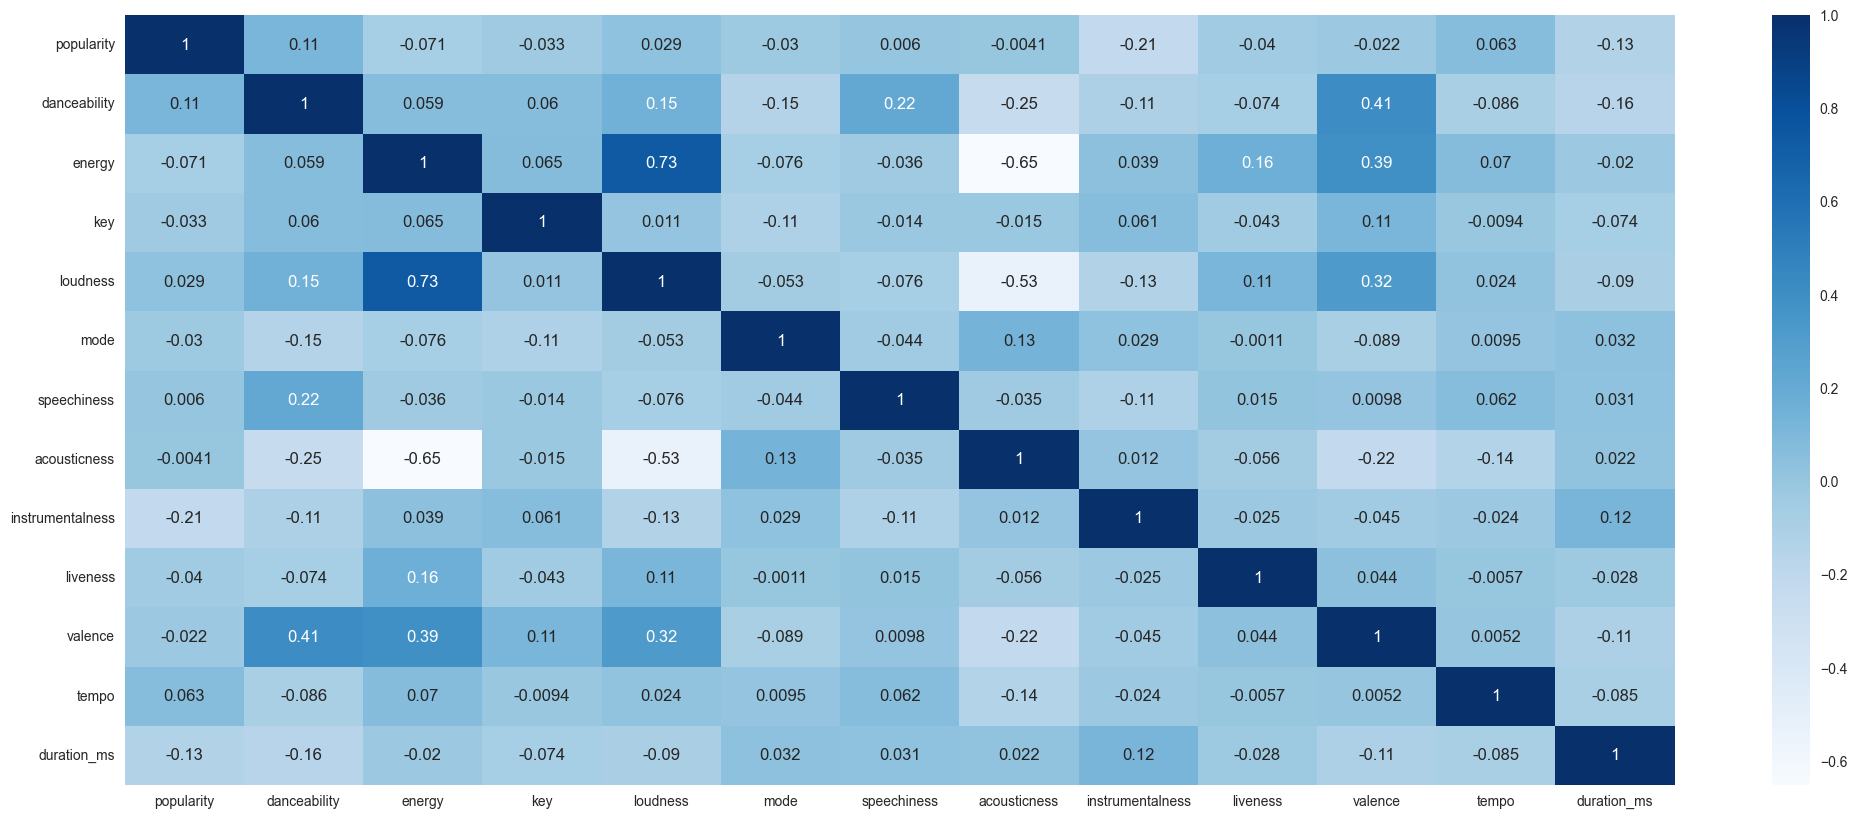

In [108]:
#Using Pearson Correlation
plt.figure(figsize=(25,10))
corr = corr_data.corr()
sns.heatmap(corr, annot=True, cmap=plt.cm.Blues)
plt.show()

#### **Using Kmeans to find number of clusters to use**

In [109]:
# Min Max Scaler
names = corr_data.columns
indexes = corr_data.index
sc = MinMaxScaler((0, 1))
df = sc.fit_transform(corr_data)
data_scaled = pd.DataFrame(df, columns=names, index=indexes)
data_scaled.head()

,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
unique_no,,,,,,,,,,,,,
748675556,0.764706,0.505275,0.787699,0.727273,0.913999,1.0,0.035407,0.009948,0.000000,0.148914,0.443486,0.638422,0.016810
3314651160,0.670588,0.397421,0.944843,0.090909,0.895220,0.0,0.194381,0.000208,0.000004,0.605263,0.613891,0.711459,0.031203
1125341062,0.823529,0.712778,0.770007,0.636364,0.857014,1.0,0.114106,0.092569,0.000000,0.057749,0.949310,0.652681,0.025033
3481502115,0.741176,0.939039,0.638880,0.545455,0.869450,0.0,0.155677,0.049998,0.000000,0.036967,0.786454,0.283331,0.025252
2475379633,0.823529,0.595545,0.786658,0.545455,0.837637,1.0,0.121273,0.016565,0.000006,0.025898,0.802632,0.420675,0.016292


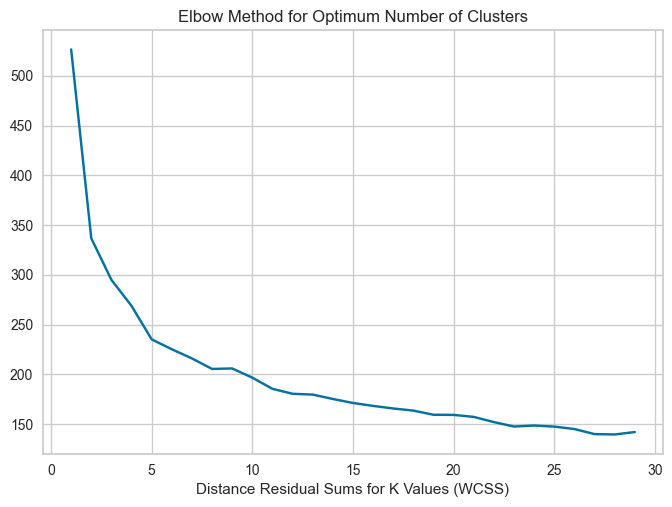

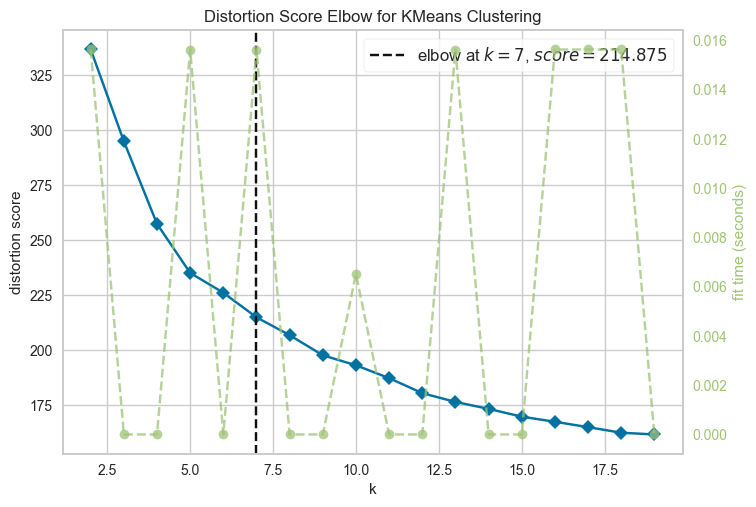

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [110]:
# Selecting numbers of cluster to create
kmeans = KMeans()
ssd = []
K = range(1, 30)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(data_scaled)
    ssd.append(kmeans.inertia_)

ssd

plt.plot(K, ssd, "bx-")
plt.xlabel("Distance Residual Sums for K Values (WCSS)")
plt.title("Elbow Method for Optimum Number of Clusters")
plt.show()

kmeans = KMeans(random_state=123)
visu = KElbowVisualizer(kmeans, k=(2, 20))
visu.fit(df)
visu.show()

In [111]:
# Ensure data_scaled and corr_data have the same index
assert len(data_scaled) == len(corr_data), "Mismatch in data lengths"

# Apply PCA
pca = PCA(n_components=2)
data_scaled[['X', 'Y']] = pca.fit_transform(data_scaled)

# KMeans clustering
kmeans = KMeans(n_clusters=7, random_state=123).fit(data_scaled[['X', 'Y']])
clusters = kmeans.labels_

# Merge PCA results with original data
Kmean_cluster_df = corr_data.copy()
Kmean_cluster_df[['X', 'Y']] = data_scaled[['X', 'Y']].values
Kmean_cluster_df["ClusterGroup"] = clusters

# Create DataFrame with CaseID and Clusters
cluster_df = pd.DataFrame({
    "CaseID": Kmean_cluster_df.index,
    "Clusters": clusters
})

Kmean_cluster_df.head()


,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,X,Y,ClusterGroup
unique_no,,,,,,,,,,,,,,,,
748675556,74,0.544,0.786,8,-2.970,1,0.0501,0.009910,0.000000,0.1690,0.446,153.967,157138,0.318931,0.357677,4
3314651160,66,0.452,0.937,1,-3.346,0,0.1610,0.000209,0.000004,0.6060,0.604,164.032,209598,-0.587418,-0.297800,5
1125341062,79,0.721,0.769,7,-4.111,1,0.1050,0.092200,0.000000,0.0817,0.915,155.932,187108,0.283109,0.435022,4
3481502115,72,0.914,0.643,6,-3.862,0,0.1340,0.049800,0.000000,0.0618,0.764,105.033,187907,-0.680036,0.105363,0
2475379633,79,0.621,0.785,6,-4.499,1,0.1100,0.016500,0.000006,0.0512,0.779,123.960,155253,0.307791,0.312606,1


In [112]:
#Merge cluster to original dataset

cluster_df = Kmean_cluster_df[['X', 'Y', 'ClusterGroup']]
full_cluster_data = pd.merge(cluster_data, cluster_df, left_index=True, right_index=True)
full_cluster_data.head()

,artist,main_artist,feature_artist,song,start_of_week,end_of_week,is_new_entry,is_reentry,position,position_change,...,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,song_release_year,X,Y,ClusterGroup
unique_no,,,,,,,,,,,,,,,,,,,,,
18931416,sigala,sigala,NaN,melody,2022-01-28,2022-02-03,True,False,65,0,...,0.000002,0.125,0.525,123.017,167142,4,2022,-0.703029,0.371634,3
18931416,sigala,sigala,NaN,melody,2022-02-04,2022-02-10,False,False,73,-8,...,0.000002,0.125,0.525,123.017,167142,4,2022,-0.703029,0.371634,3
18931416,sigala,sigala,NaN,melody,2022-02-11,2022-02-17,False,False,70,3,...,0.000002,0.125,0.525,123.017,167142,4,2022,-0.703029,0.371634,3
18931416,sigala,sigala,NaN,melody,2022-02-18,2022-02-24,False,False,53,17,...,0.000002,0.125,0.525,123.017,167142,4,2022,-0.703029,0.371634,3
18931416,sigala,sigala,NaN,melody,2022-02-25,2022-03-03,False,False,47,6,...,0.000002,0.125,0.525,123.017,167142,4,2022,-0.703029,0.371634,3


In [113]:
# Plot Song Clusters
fig = px.scatter(full_cluster_data, x='X', y='Y', color='ClusterGroup', title='Song Clusters')
fig.show()

![title](images/clusters.png)

#### **Building recommender using NearestNeighbors model**

In [114]:
def build_song_recommender(song_df, feature_columns=None, n_neighbors=7):
    """
    Builds a song recommender system using audio features.

    Args:
        song_df (pd.DataFrame): DataFrame containing song data.
        feature_columns (list): List of feature column names to use for similarity.
        n_neighbors (int): Number of similar songs to recommend.

    Returns:
        function: A function that takes a song title and artist name and returns recommendations.
    """
    # Default feature columns if not provided
    if feature_columns is None:
        feature_columns = ['popularity','danceability','energy','key','loudness','mode',
                           'speechiness','acousticness','instrumentalness','liveness','valence','tempo']

    # Drop rows with missing values in feature columns
    df_filtered = song_df.dropna(subset=feature_columns + ['song', 'artist']).copy()

    # Normalize the feature columns
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(df_filtered[feature_columns])

    # Fit Nearest Neighbors model
    nn_model = NearestNeighbors(n_neighbors=n_neighbors + 1, metric='euclidean')
    nn_model.fit(features_scaled)

    def recommend(song_title, artist_name):
        """
        Recommends similar songs based on audio features.

        Args:
            song_title (str): Title of the song to find similar songs for.
            artist_name (str): Name of the artist.

        Returns:
            pd.DataFrame: DataFrame of recommended songs.
        """
        # Find the index of the song in the filtered DataFrame
        mask = (df_filtered['song'].str.lower() == song_title.lower()) & (df_filtered['artist'].str.lower() == artist_name.lower())
        if not mask.any():
            print("Song not found in dataset.")
            return pd.DataFrame()

        idx = df_filtered[mask].index[0]
        # Get the position of the song in the filtered DataFrame
        position = df_filtered.index.get_loc(idx)
        song_vector = features_scaled[position].reshape(1, -1)

        # Find nearest neighbors
        distances, indices = nn_model.kneighbors(song_vector)

        # Exclude the first result (itself)
        recommended_indices = indices[0][1:]
        recommendations = df_filtered.iloc[recommended_indices][['song', 'artist'] + feature_columns].copy()
        recommendations['SimilarityScore'] = distances[0][1:]

        return recommendations.reset_index(drop=True)

    return recommend



In [115]:
df_output = pd.read_csv('data/spotify_kaggle_data/improved_song_data_with_spotify_data.csv')

#Prepare data
recommender_data = df_output[['artist','song','popularity','danceability','energy','key','loudness','mode','speechiness','acousticness',
                              'instrumentalness','liveness','valence','tempo','duration_ms']]
recommender_data = recommender_data.drop_duplicates()
recommender_data.head()

,artist,song,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,leah kate,10 things i hate about you,74,0.544,0.786,8,-2.970,1,0.0501,0.009910,0.000000,0.1690,0.446,153.967,157138
13,bring me the horizon and nova,1x1,66,0.452,0.937,1,-3.346,0,0.1610,0.000209,0.000004,0.6060,0.604,164.032,209598
14,lizzo,2 be loved (am i ady),79,0.721,0.769,7,-4.111,1,0.1050,0.092200,0.000000,0.0817,0.915,155.932,187108
38,wizkid ft. ayra starr,2 sugar,72,0.914,0.643,6,-3.862,0,0.1340,0.049800,0.000000,0.0618,0.764,105.033,187907
39,nathan dawe ft. ella henderson,21 asons,79,0.621,0.785,6,-4.499,1,0.1100,0.016500,0.000006,0.0512,0.779,123.960,155253


In [116]:
# Build the recommender
recommender = build_song_recommender(recommender_data)

In [117]:
#Testing the model
song = '10 things i hate about you'
artist = 'leah kate'
results = recommender(song, artist)

if not results.empty:
    # Save results to a DataFrame (if not already one)
    if not isinstance(results, pd.DataFrame):
        results_df = pd.DataFrame(results)
    else:
        results_df = results
else:
    print("No recommendations found.")
    
results_df = results_df[['artist', 'song', 'popularity']]
results_df

,artist,song,popularity
0,tom grennan,all these nights,65
1,ava max,maybe you' the problem,71
2,taylor swift,you belong with me (taylor's version),79
3,tom grennan,mind me,68
4,taylor swift,state of grace (taylor's version),66
5,blink 182,edging,68
6,sam fender,getting started,62


In [118]:
song = "we' good"
artist = 'dua lipa'
results = recommender(song, artist)

# if not results.empty:
#     print(f"\nSongs similar to '{song}' by {artist}:\n")
#     print(results)
# else:
#     print("No recommendations found.")

if not results.empty:
    # Save results to a DataFrame (if not already one)
    if not isinstance(results, pd.DataFrame):
        results_df = pd.DataFrame(results)
    else:
        results_df = results
else:
    print("No recommendations found.")
    
results_df = results_df[['artist', 'song', 'popularity']]
results_df

,artist,song,popularity
0,blackpink,lovesick girls,71
1,internet money and juice wrld and redd,blastoff,64
2,miley cyrus,angels like you,80
3,tones and i,fly away,65
4,clean bandit ft. a7s,everything but you,66
5,taylor swift,wildest dams (taylor's version),80
6,bts,butter,71


In [119]:
song = "what's next"
artist = 'drake'
results = recommender(song, artist)

if not results.empty:
    # Save results to a DataFrame (if not already one)
    if not isinstance(results, pd.DataFrame):
        results_df = pd.DataFrame(results)
    else:
        results_df = results
else:
    print("No recommendations found.")
    
results_df = results_df[['artist', 'song', 'popularity']]
results_df

,artist,song,popularity
0,swedish house mafia,heaven takes you home,76
1,swedish house mafia and connie,heaven takes you home,76
2,justin bieber,hold on,74
3,mist,savage,68
4,dj khaled and drake and lil baby,staying alive,71
5,ty dolla sign ft. post malone,spicy,70
6,travis scott,mafia,69


## **4. Store processed data - Tabular and Graph format**

### **Store processed file in a ralational database**

In [120]:
from langchain_community.utilities import SQLDatabase
from langchain_ollama import ChatOllama
from langchain_community.agent_toolkits import create_sql_agent
from langchain.schema import SystemMessage
from langchain.chains import create_sql_query_chain
from langchain_community.tools.sql_database.tool import QuerySQLDataBaseTool
from langchain_core.runnables import RunnableLambda
from operator import itemgetter
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
import sqlite3
import csv
import json

In [121]:
# Infer SQLite-compatible data types from pandas dtypes
def map_dtype(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return "INTEGER"
    elif pd.api.types.is_float_dtype(dtype):
        return "REAL"
    elif pd.api.types.is_bool_dtype(dtype):
        return "BOOLEAN"
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return "TEXT"
    else:
        return "TEXT"

In [122]:
# Path to your CSV file
csv_file_path = 'data/final/uktop100musicchart.csv'
table_name = 'uktop100chart'

In [123]:
# Load the csv to get column data types
sqlite_df = pd.read_csv(csv_file_path)  
sqlite_df = sqlite_df.drop(columns = ['artist'])
sqlite_df = sqlite_df.dropna(subset=["main_artist"])
sqlite_df = sqlite_df.drop_duplicates()    
sqlite_df['average_peak_position_by_artist'] = sqlite_df['average_peak_position_by_artist'].apply(lambda x: round(x, 2))
sqlite_df['start_of_week']= pd.to_datetime(sqlite_df['start_of_week'].str.strip(), format='%Y-%m-%d')
sqlite_df['end_of_week']= pd.to_datetime(sqlite_df['end_of_week'].str.strip(), format='%Y-%m-%d')
sqlite_df['last_week_date_on_chart']= pd.to_datetime(sqlite_df['last_week_date_on_chart'].str.strip(), format='%Y-%m-%d')
sqlite_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 285951 entries, 0 to 285999
Data columns (total 27 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   unique_no                        285951 non-null  int64         
 1   main_artist                      285951 non-null  object        
 2   collaborating_artist             23971 non-null   object        
 3   song                             285951 non-null  object        
 4   start_of_week                    285951 non-null  datetime64[ns]
 5   end_of_week                      285951 non-null  datetime64[ns]
 6   is_new_entry                     285951 non-null  bool          
 7   is_reentry                       285951 non-null  bool          
 8   position                         285951 non-null  int64         
 9   position_change                  285951 non-null  int64         
 10  weeks_on_chart_total             285951 non-

In [124]:
# Generate CREATE TABLE statement
columns_with_types = ", ".join([f'"{col}" {map_dtype(dtype)}' for col, dtype in sqlite_df.dtypes.items()])
create_table_sql = f'CREATE TABLE IF NOT EXISTS {table_name} ({columns_with_types});'

In [125]:
# Connect to SQLite and create table
with sqlite3.connect("dacoe.db") as conn:
    cursor = conn.cursor()
    cursor.execute(f'DROP TABLE IF EXISTS {table_name};')
    cursor.execute(create_table_sql)

    # Insert data into the table
    sqlite_df.to_sql(table_name, conn, if_exists='append', index=False)


print("Table created with inferred schema and data inserted successfully.")
conn.close()

Table created with inferred schema and data inserted successfully.


In [126]:
# Connect to your SQLite database
conn = sqlite3.connect('dacoe.db')
cursor = conn.cursor()

# Replace 'uktop100chart' with your actual table name
cursor.execute("PRAGMA table_info(uktop100chart);")
schema_info = cursor.fetchall()

# Display schema
for column in schema_info:
    print(column)
    

(0, 'unique_no', 'INTEGER', 0, None, 0)
(1, 'main_artist', 'TEXT', 0, None, 0)
(2, 'collaborating_artist', 'TEXT', 0, None, 0)
(3, 'song', 'TEXT', 0, None, 0)
(4, 'start_of_week', 'TEXT', 0, None, 0)
(5, 'end_of_week', 'TEXT', 0, None, 0)
(6, 'is_new_entry', 'BOOLEAN', 0, None, 0)
(7, 'is_reentry', 'BOOLEAN', 0, None, 0)
(8, 'position', 'INTEGER', 0, None, 0)
(9, 'position_change', 'INTEGER', 0, None, 0)
(10, 'weeks_on_chart_total', 'REAL', 0, None, 0)
(11, 'peak', 'REAL', 0, None, 0)
(12, 'first_week_position', 'REAL', 0, None, 0)
(13, 'previous_week_position', 'INTEGER', 0, None, 0)
(14, 'last_week_date_on_chart', 'TEXT', 0, None, 0)
(15, 'consecutive_weeks_on_chart', 'REAL', 0, None, 0)
(16, 'total_songs_by_artist', 'REAL', 0, None, 0)
(17, 'average_peak_position_by_artist', 'REAL', 0, None, 0)
(18, 'longest_charting_song_by_artist', 'TEXT', 0, None, 0)
(19, 'week_number', 'INTEGER', 0, None, 0)
(20, 'month', 'INTEGER', 0, None, 0)
(21, 'year', 'INTEGER', 0, None, 0)
(22, 'season', 

In [127]:
# Test that table exist in the database and can be queried
# Query the top 5 rows and display as a DataFrame
cursor.execute(f"SELECT * FROM {table_name} LIMIT 5") # 
rows = cursor.fetchall()

# Get column names from the cursor description
columns = [description[0] for description in cursor.description]

# Create and display DataFrame
df = pd.DataFrame(rows, columns=columns)
df


,unique_no,main_artist,collaborating_artist,song,start_of_week,end_of_week,is_new_entry,is_reentry,position,position_change,...,average_peak_position_by_artist,longest_charting_song_by_artist,week_number,month,year,season,album,duration,deezer_link,genre
0,2369804095,VERA LYNN,None,AUF WIEDERSEH'N SWEETHEART,1952-11-14T00:00:00,1952-11-20T00:00:00,1,0,10,0,...,12.15,A HOUSE WITH LOVE IN IT,46,11,1952,AUTUMN,VERA LYNN 100,160.0,HTTPS://WWW.DEEZER.COM/TRACK/144388690,CLASSICAL
1,6888476700,MAX BYGRAVES,None,COWPUNCHER'S CANTATA,1952-11-14T00:00:00,1952-11-20T00:00:00,1,0,11,0,...,13.05,TULIPS FROM AMSTERDAM AND YOU NEED HANDS,46,11,1952,AUTUMN,BRITAIN'S FIRST SINGLES CHART,195.0,HTTPS://WWW.DEEZER.COM/TRACK/514781462,POP
2,9991277551,GUY MITCHELL,None,FEET UP (PAT HIM ON THE PO-PO),1952-11-14T00:00:00,1952-11-20T00:00:00,1,0,5,0,...,3.73,SINGING THE BLUES,46,11,1952,AUTUMN,SINGIN' THE BLUES,160.0,HTTPS://WWW.DEEZER.COM/TRACK/140979339,FOLK
3,4158082603,FRANKIE LAINE,None,HIGH NOON (DO NOT FORSAKE ME),1952-11-14T00:00:00,1952-11-20T00:00:00,1,0,7,0,...,4.34,I BELIEVE,46,11,1952,AUTUMN,HELL BENT FOR LEATHER!,144.0,HTTPS://WWW.DEEZER.COM/TRACK/495173092,POP
4,3839992792,RAY MARTIN,None,BLUE TANGO,1952-11-14T00:00:00,1952-11-20T00:00:00,1,0,8,0,...,10.15,SWEDISH RHAPSODY,46,11,1952,AUTUMN,BRITAIN'S FIRST SINGLES CHART,170.0,HTTPS://WWW.DEEZER.COM/TRACK/514781492,POP


#### **Using Natural Language to query the database with Large Language Model (LLM)**

In [128]:
db_path = "dacoe.db"
db = SQLDatabase.from_uri(f"sqlite:///{db_path}")

In [129]:
db

In [130]:
# validate the connection to the vectordb
print(db.dialect)

sqlite


In [131]:
print(db.get_usable_table_names())

['uktop100chart']


In [132]:
db.run("SELECT * FROM uktop100chart LIMIT 5;")

'[(2369804095, \'VERA LYNN\', None, "AUF WIEDERSEH\'N SWEETHEART", \'1952-11-14T00:00:00\', \'1952-11-20T00:00:00\', 1, 0, 10, 0, 1.0, 10.0, 10.0, 0, \'1952-11-14T00:00:00\', 0.0, 11.0, 12.15, \'A HOUSE WITH LOVE IN IT\', 46, 11, 1952, \'AUTUMN\', \'VERA LYNN 100\', 160.0, \'HTTPS://WWW.DEEZER.COM/TRACK/144388690\', \'CLASSICAL\'), (6888476700, \'MAX BYGRAVES\', None, "COWPUNCHER\'S CANTATA", \'1952-11-14T00:00:00\', \'1952-11-20T00:00:00\', 1, 0, 11, 0, 5.0, 7.0, 11.0, 0, \'1953-03-06T00:00:00\', 0.0, 18.0, 13.05, \'TULIPS FROM AMSTERDAM AND YOU NEED HANDS\', 46, 11, 1952, \'AUTUMN\', "BRITAIN\'S FIRST SINGLES CHART", 195.0, \'HTTPS://WWW.DEEZER.COM/TRACK/514781462\', \'POP\'), (9991277551, \'GUY MITCHELL\', None, \'FEET UP (PAT HIM ON THE PO-PO)\', \'1952-11-14T00:00:00\', \'1952-11-20T00:00:00\', 1, 0, 5, 0, 9.0, 2.0, 5.0, 0, \'1953-01-09T00:00:00\', 0.0, 15.0, 3.73, \'SINGING THE BLUES\', 46, 11, 1952, \'AUTUMN\', "SINGIN\' THE BLUES", 160.0, \'HTTPS://WWW.DEEZER.COM/TRACK/14097933

In [133]:
# Describtion

table_describtion = "This is an weekly historical data of the UK Top 100 songs between 1952 to 2024."

column_descriptions = """
      artist - Combination of main_artist and collaborating artist
      main_artist - Name of the artist that owns the song.
      collaborating_artist - Name of the artist that was featured in the song.
      song - Title of the song.
      start_of_week - start date of the week.
      end_of_week - end date of the week.
      is_new_entry - Whether the song is a new entry this week.
      is_reentry - Whether the song has re-entered the chart.
      position - position of song on the chart for the week.
      position_change - Change in position compared to the previous week.
      weeks_on_chart_total - Total number of weeks the song has appeared on the chart.
      peak - The highest position the song has reached (1 = highest and 100 = lowest).
      first_week_position - The position the song debuted at.
      previous_week_position - The song's position in the previous week (0 if new or 101 if re-entry).
      last_week_date_on_chart - The last date the song appeared on the chart.
      consecutive_weeks_on_chart - Number of consecutive weeks the song has been on the chart.
      total_songs_by_artist - Total number of songs by the artist in the dataset.
      average_peak_position_by_artist - Average peak position of all songs by the artist.
      longest_charting_song_by_artist - The artist's song with the longest chart run.
      week_number - week number or start_of_week.
      month - month number for start_of_week.
      year" - year for start_of_week.
      season - season of the year.
      album - he title of the album
      duration - The length of the song in seconds
      deezer_link - The url link to get more detail of the song
      genre  - The genre of the artist

      """

In [134]:
# Define the system prompt

system_message = SystemMessage(
    content=f"""
            You are a SQLite expert. Given an input question, first create a syntactically correct SQLite query to run, 
            then look at the results of the query and return the answer to the input question. 
                       
            You can order the results to return the most informative data in the database.
            
            Never query for all columns from a table. You must query only the columns that are needed to answer the question. 
            Wrap each column name in double quotes (") to denote them as delimited identifiers.

            Unless the user specifies in the question a specific number of examples to obtain, query for at most 5 results using the LIMIT 
            clause as per SQLite.
            
            Pay attention to use only the column names you can see in the tables below. 
            
            Be careful to not query for columns that do not exist. Also, pay attention to which column is in which table.
            
            Pay attention to use date('now') function to get the current date, if the question involves "today".
            
            Use the following format:
            
            Question: Question here
            SQLQuery: SQL Query to run
            SQLResult: Result of the SQLQuery
            Answer: Final answer here
            
            Question: {input}

            Only use the following tables:
            {table_name} 

            Table description: 
            
            {table_describtion}

            Column describtions: 
            {column_descriptions}

            Here are examples of Queries and Answer 

            Example 1 
            ```
            Question: What are the top 5 songs with the longest duration?
            
            SQLQuery:
            SELECT "song", "main_artist", "duration"
            FROM {table_name}
            ORDER BY "duration" DESC
            LIMIT 5;
            
            SQLResult:
            [...]
            Answer:
            Here are the top 5 longest songs in the chart, led by...
            ```
            
            Example 2  
            ```
            Question: Which artists had new entries this week?
            
            SQLQuery:
            SELECT DISTINCT "main_artist"
            FROM {table_name}
            WHERE "is_new_entry" = 1
            AND "start_of_week" = date('now')
            LIMIT 5;
            
            SQLResult:
            [...]
            Answer:
            These artists had new entries this week...
            ```
            
            Example 3 
            ```
            Question: What is the average peak position of Vera Lynn's songs?
            
            SQLQuery:
            SELECT AVG("peak")
            FROM {table_name}
            WHERE "main_artist" = 'vera lynn';
            
            SQLResult:
            [...]
            Answer:
            Vera Lynn's songs have an average peak position of...
            ```
            
            Example 4  
            ```
            Question: List the top 5 songs by chart position in Autumn 1952.
            
            SQLQuery:
            SELECT "song", "main_artist", "position"
            FROM {table_name}
            WHERE "season" = 'Autumn' AND "year" = 1952
            ORDER BY "position" ASC
            LIMIT 5;
            
            SQLResult:
            [...]
            Answer:
            Here are the top 5 songs from Autumn 1952...
            ```
            
            Example 5 
            ```
            Question: Which song stayed the longest on the chart?
            
            SQLQuery:
            SELECT "song", "main_artist", "weeks_on_chart_total"
            FROM {table_name}
            ORDER BY "weeks_on_chart_total" DESC
            LIMIT 1;
            
            SQLResult:
            [...]
            Answer:
            The longest-charting song is...
            ```
            
            """
)

In [135]:
# Define the LLM using Ollama with system prompt
 #qwen2.5-coder:14b gemma3:12b
llm = ChatOllama(
    model="gemma3:12b", 
    system=system_message.content, 
    temperature = 0,
    handle_parsing_errors=True
)


In [136]:
# Generate SQL query using llm
chain = create_sql_query_chain(llm, db)
response = chain.invoke({"question": "How many songs are in the chart in 2022"})
print(response)

```sql
SELECT
  COUNT(*)
FROM uktop100chart
WHERE
  YEAR = 2022;
```


In [137]:
# Strip markdown formatting from SQL query
def clean_sql_output(output):
    return output.strip().strip("```sql").strip("```").strip()

In [141]:
write_query = create_sql_query_chain(llm, db)

clean_query = RunnableLambda(clean_sql_output)
    
execute_query = QuerySQLDataBaseTool(db=db)

In [139]:
# Chain: write -> clean -> execute
chain = write_query | clean_query | execute_query

In [140]:
chain.invoke({"question": "How many songs are in the chart in 2022"})

'[(5227,)]'

In [142]:
answer_prompt = PromptTemplate.from_template(
    """
    
    Given the following user question, corresponding SQL query, and SQL result, answer the user question.

    Do not use markdown formatting like ```sql or ``` in your responses. Just return the SQL query as plain text.

    
    Question: {question}
    
    SQL Query: {query}
    
    SQL Result: {result}
    
    Answer: 
    
    """
)

In [143]:
# Final answer chain
answer = answer_prompt | llm | StrOutputParser()

# Full chain with query cleaning
chain = (
    RunnablePassthrough.assign(query=write_query)
    .assign(cleaned_query=itemgetter("query") | clean_query)
    .assign(result=itemgetter("cleaned_query") | execute_query)
    | answer
)

# Example invocation
chain.invoke({"question": "How many songs are in the chart in 2022?"})

'There are 5227 songs in the chart in 2022.'

In [144]:
chain.invoke({"question": "what is the most genre in 2021?"})

'POP'

In [145]:
chain.invoke({"question": "please list the songs released by elvis presley"})

'Elvis Presley released the songs Heartbreak Hotel and Blue Suede Shoes.'

#### **Using Langchain Agent**

In [146]:
agent_executor = create_sql_agent(llm, db=db, agent_type="zero-shot-react-description", verbose=True) 

In [147]:
agent_executor.invoke({"input": "What is the most popular genre when season is Autumn?"})



> Entering new SQL Agent Executor chain...
Action: sql_db_list_tables
Action Input: uktop100chartI see a single table named `uktop100chart`. I should query its schema to understand its columns.
Action: sql_db_schema
Action Input: uktop100chart
CREATE TABLE uktop100chart (
	unique_no INTEGER, 
	main_artist TEXT, 
	collaborating_artist TEXT, 
	song TEXT, 
	start_of_week TEXT, 
	end_of_week TEXT, 
	is_new_entry BOOLEAN, 
	is_reentry BOOLEAN, 
	position INTEGER, 
	position_change INTEGER, 
	weeks_on_chart_total REAL, 
	peak REAL, 
	first_week_position REAL, 
	previous_week_position INTEGER, 
	last_week_date_on_chart TEXT, 
	consecutive_weeks_on_chart REAL, 
	total_songs_by_artist REAL, 
	average_peak_position_by_artist REAL, 
	longest_charting_song_by_artist TEXT, 
	week_number INTEGER, 
	month INTEGER, 
	year INTEGER, 
	season TEXT, 
	album TEXT, 
	duration REAL, 
	deezer_link TEXT, 
	genre TEXT
)

/*
3 rows from uktop100chart table:
unique_no	main_artist	collaborating_artist	song	start

{'input': 'What is the most popular genre when season is Autumn?',
 'output': 'POP'}

### **Knowledge Graph Database**

**Resource**: [https://pypi.org/project/neo4j-runway/]

In [181]:
from neo4j_runway import Discovery
from neo4j_runway import GraphDataModeler
from neo4j_runway.code_generation import PyIngestConfigGenerator
from neo4j_runway import UserInput
from neo4j_runway.llm.openai import OpenAIDiscoveryLLM
from neo4j_runway.llm.openai import OpenAIDataModelingLLM
from neo4j_runway.utils import test_database_connection

from neo4j_runway import PyIngest
from IPython.display import display
from IPython.display import Image
from IPython.display import Markdown

import json
import textwrap
#from langchain_neo4j import Neo4jGraph
from langchain_community.graphs import Neo4jGraph

In [228]:
graph_df = enriched_combined_df.copy()
graph_df = graph_df.dropna(subset=["main_artist"])
# Reducing the data to start from 1970 as there is a limit on nodes and relationships that can be created in the free version of neo4j aura
graph_df = graph_df[graph_df['year'] > 1969]
graph_df['collaborating_artist'] = graph_df['collaborating_artist'].fillna('None')
graph_df = graph_df.drop_duplicates()

In [229]:
graph_df.head()

,unique_no,artist,main_artist,collaborating_artist,song,start_of_week,end_of_week,is_new_entry,is_reentry,position,...,average_peak_position_by_artist,longest_charting_song_by_artist,week_number,month,year,season,album,duration,deezer_link,genre
53890,549170729,delaney and bonnie and friends,delaney and bonnie and friends,None,comin' home,1970-01-04,1970-01-10,False,False,19,...,16.00,comin' home,1,1,1970,Winter,On Tour With Eric Clapton,412.0,https://www.deezer.com/track/5616979,Rock
326339,7494345050,tom jones,tom jones,None,without love (the is nothing),1970-01-04,1970-01-10,False,False,13,...,11.57,help yourself,1,1,1970,Winter,The Best Of ... Tom Jones,223.0,https://www.deezer.com/track/525870032,Pop
283963,5266813227,harry j all stars,harry j all stars,None,the liquidator,1970-01-04,1970-01-10,False,False,10,...,9.00,the liquidator,1,1,1970,Winter,Liquidator: The Best of The Harry J All Stars,172.0,https://www.deezer.com/track/131293626,Reggae
42001,9228321414,jim reeves,jim reeves,None,but you love me daddy,1970-01-04,1970-01-10,False,False,17,...,14.40,i love you because,1,1,1970,Winter,Cline Vs. Reeves - She's Got You,128.0,https://www.deezer.com/track/571621432,Country
116166,8572793607,vanity fare,vanity fare,None,hitchin' a ride,1970-01-04,1970-01-10,False,False,32,...,14.18,hitchin' a ride,1,1,1970,Winter,Early in the Morning,188.0,https://www.deezer.com/track/515170022,Pop


In [230]:
graph_df.shape

(251231, 28)

In [231]:
#Keep copy of graph_df
#graph_df.to_csv('data/neo4j/graph_df.csv', index = False)

In [232]:
graph_df.columns.to_list()

['unique_no',
 'artist',
 'main_artist',
 'collaborating_artist',
 'song',
 'start_of_week',
 'end_of_week',
 'is_new_entry',
 'is_reentry',
 'position',
 'position_change',
 'weeks_on_chart_total',
 'peak',
 'first_week_position',
 'previous_week_position',
 'last_week_date_on_chart',
 'consecutive_weeks_on_chart',
 'total_songs_by_artist',
 'average_peak_position_by_artist',
 'longest_charting_song_by_artist',
 'week_number',
 'month',
 'year',
 'season',
 'album',
 'duration',
 'deezer_link',
 'genre']

In [233]:
USER_GENERATED_INPUT = UserInput(
  general_description='This is an weekly historical data of the UK Top 100 songs between 1970 to 2024.',
  column_descriptions={
      "unique_no" : "Unique identifier for a song realeased by the main_artist",
      "artist" : "Combination of main_artist and collaborating artist",
    "main_artist" : "Name of the artist that owns the song.",
    "collaborating_artist" : "Name of the artist that was featured in the song.",
    "song" : "Title of the song.",
    "start_of_week" : "start date of the week.",
    "end_of_week" : "end date of the week.",
    "is_new_entry" : "Whether the song is a new entry this week.",
    "is_reentry" : "Whether the song has re-entered the chart.",
    "position" : "position of song on the chart for the week.",
    "position_change" : "Change in position compared to the previous week.",
    "weeks_on_chart_total" : "Total number of weeks the song has appeared on the chart.",
    "peak" :"The highest position the song has reached (1 = highest and 100 = lowest).",
    "first_week_position" : "The position the song debuted at.",
    "previous_week_position" : "The song's position in the previous week (0 if new or 101 if re-entry).",
    "last_week_date_on_chart" : "The last date the song appeared on the chart.",
    "consecutive_weeks_on_chart" : "Number of consecutive weeks the song has been on the chart.",
    "total_songs_by_artist" : "Total number of songs by the artist in the dataset." ,
    "average_peak_position_by_artist" : "Average peak position of all songs by the artist.",
    "longest_charting_song_by_artist" : "The artist's song with the longest chart run.",
    "week_number" : "week number or start_of_week.",
    "month" : "month number for start_of_week.",
    "year" : "year for start_of_week.",
    "season" : "season of the year.",
      "album" : "The title of the album",
      "duration" : "The length of the song in seconds",
      "deezer_link" : "The url link to get more detail of the song",
      "genre" : "The genre of the artist"},
  use_cases=["Has there a change in the most popular genres over the past 40 years from pop to rock to hiphop?",
             "What impact did Britpop have on the 90s or Indie in the 00s?",
             "Which artist have the most songs on the chart in the last 20 years?",
             "Do albums of certain genres have better longevity?",
             "What is the best performing song in 2022?",
             "What is the most popular genre in 2021?",
             "What is the best performing song by Taylor Swift?"]  
)



In [234]:
llm_disc = OpenAIDiscoveryLLM(model_name='gpt-4o', model_params={"temperature": 0})
llm_dm = OpenAIDataModelingLLM(model_name='gpt-4o', model_params={"temperature": 0.5})

In [235]:
disc = Discovery(llm=llm_disc, user_input=USER_GENERATED_INPUT, data=graph_df)
disc.run(show_result=True, notebook=True)

### Preliminary Analysis of UK Top 100 Songs Data

#### Overall Details:
- **Data Size and Structure**: The dataset contains 251,231 entries with 28 features, covering weekly chart data from 1970 to 2024.
- **Data Completeness**: All columns are non-null, indicating a complete dataset without missing values.
- **Data Types**: The dataset includes a mix of data types: integers, floats, booleans, datetime, and objects (strings).

#### Important Features for Use Cases:
1. **Genre**:
   - The `genre` column is crucial for analyzing trends in music popularity over time, such as shifts from pop to rock to hip-hop.
   - With 28 unique genres, this feature can help identify the most popular genres in specific years, such as 2021.

2. **Year and Season**:
   - The `year` and `season` columns are essential for temporal analysis, such as understanding the impact of Britpop in the 90s or Indie in the 00s.
   - These features allow for the examination of trends over decades and seasonal impacts on music popularity.

3. **Artist and Main Artist**:
   - The `artist` and `main_artist` columns are key to identifying which artists have dominated the charts, especially in the last 20 years.
   - These features can also help determine the best-performing songs by specific artists, such as Taylor Swift.

4. **Position and Peak**:
   - The `position` and `peak` columns provide insights into the performance of songs on the charts, helping to identify the best-performing songs in specific years, like 2022.
   - These features are also useful for analyzing the longevity and peak performance of songs and albums.

5. **Album and Duration**:
   - The `album` column, along with `genre`, can be used to assess whether albums of certain genres have better longevity on the charts.
   - The `duration` of songs might also correlate with their chart performance and longevity.

6. **Weeks on Chart and Consecutive Weeks**:
   - These features (`weeks_on_chart_total` and `consecutive_weeks_on_chart`) are important for understanding the longevity of songs and albums on the charts.

7. **Song and Deezer Link**:
   - The `song` column is necessary for identifying specific songs, such as the best-performing song in 2022.
   - The `deezer_link` provides additional context and details about the songs, which might be useful for deeper analysis.

#### Insights for Use Cases:
- **Genre Trends**: By analyzing the `genre` and `year` columns, we can track changes in popular genres over the decades.
- **Impact of Britpop and Indie**: The `year`, `genre`, and `position` columns can help assess the impact of Britpop in the 90s and Indie in the 00s.
- **Top Artists**: The `main_artist` column can be used to identify artists with the most chart entries in the last 20 years.
- **Album Longevity**: The `album`, `genre`, and `weeks_on_chart_total` columns can help determine if certain genres have albums with better longevity.
- **Best Performing Songs**: The `position`, `peak`, and `year` columns are crucial for identifying the best-performing songs in specific years and by specific artists.

In [189]:
# instantiate graph data modeler
gdm = GraphDataModeler(llm=llm_dm, discovery=disc)
gdm.create_initial_model()

> Generating Nodes...
Attempts | 2  
Received Valid Nodes
Nodes
* (:Song)                  * (:Artist)
* (:CollaboratingArtist)   * (:Genre)
* (:Album)                 * (:ChartEntry)
* (:TimePeriod)             

> Generating Data Model...
Attempts | 1  
Received Valid Data Model
Nodes
* (:Song)                  * (:Artist)
* (:CollaboratingArtist)   * (:Genre)
* (:Album)                 * (:ChartEntry)
* (:TimePeriod)             

Relationships
* (:Song)-[:PERFORMED_BY]->(:Artist)            
* (:Song)-[:FEATURES]->(:CollaboratingArtist)   
* (:Song)-[:BELONGS_TO]->(:Genre)               
* (:Song)-[:IN_ALBUM]->(:Album)                 
* (:Song)-[:CHART_ENTRY]->(:ChartEntry)         
* (:ChartEntry)-[:OCCURRED_IN]->(:TimePeriod)   


DataModel(nodes=[Node(label='Song', properties=[Property(name='uniqueNo', type='str', column_mapping='unique_no', alias=None, is_unique=True, part_of_key=False), Property(name='title', type='str', column_mapping='song', alias=None, is_unique=False, part_of_key=False), Property(name='duration', type='int', column_mapping='duration', alias=None, is_unique=False, part_of_key=False), Property(name='deezerLink', type='str', column_mapping='deezer_link', alias=None, is_unique=False, part_of_key=False)], source_name='file'), Node(label='Artist', properties=[Property(name='mainArtist', type='str', column_mapping='main_artist', alias=None, is_unique=True, part_of_key=False), Property(name='totalSongs', type='int', column_mapping='total_songs_by_artist', alias=None, is_unique=False, part_of_key=False), Property(name='averagePeakPosition', type='float', column_mapping='average_peak_position_by_artist', alias=None, is_unique=False, part_of_key=False), Property(name='longestChartingSong', type='str

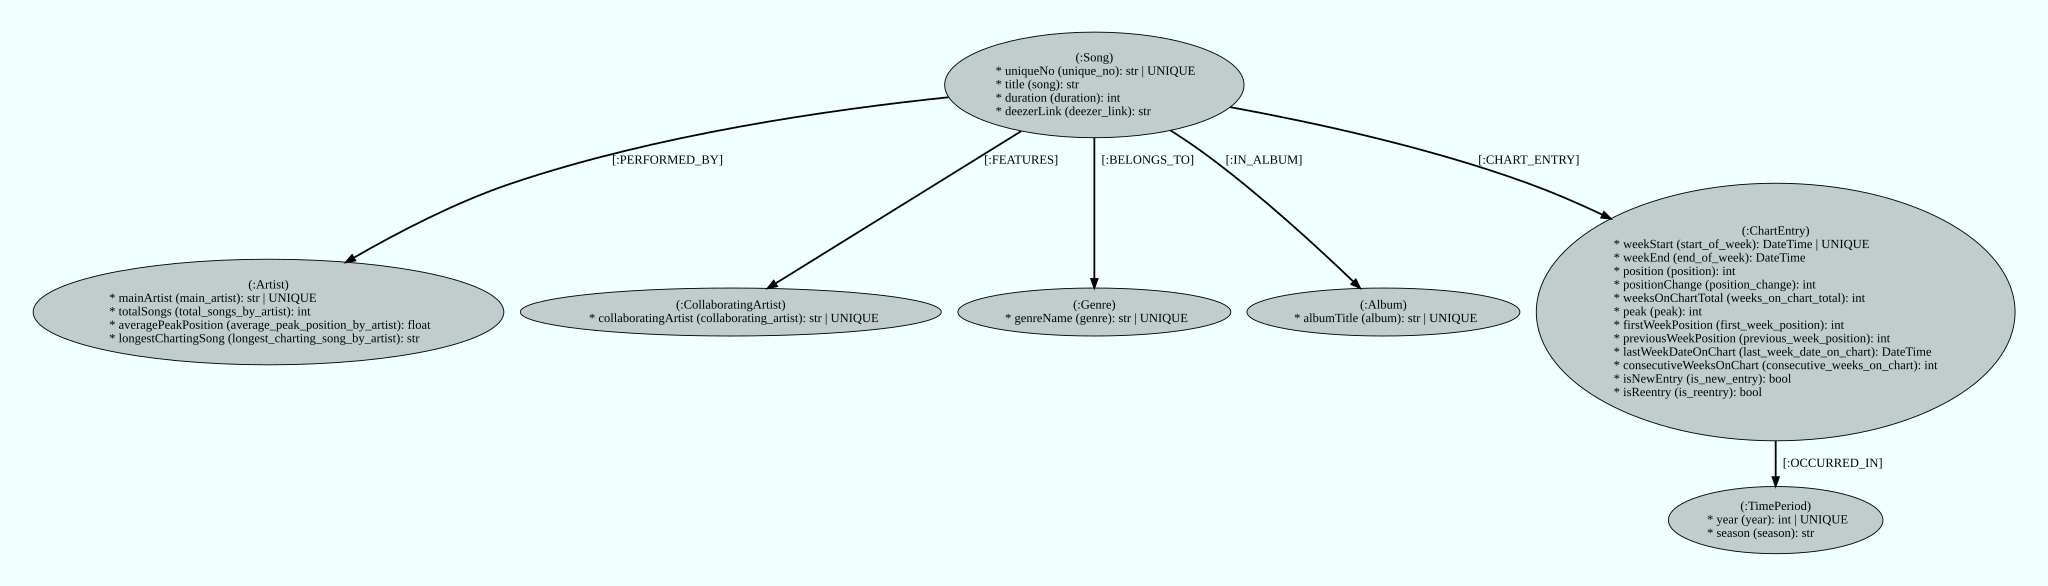

In [190]:
# visualize the data model
gdm.current_model.visualize()

In [236]:
gdm.iterate_model(user_corrections='''

Let's think step by step. Please make the following updates to the data model:
1. Remove properties position, position_change, weeks_on_chart_total, peak,first_week_position, last_week_on_chart, consecutive_weeks_on_chart, 
previous_week_position, is_new_entry and is_reentry from ChartWeek
2. Rename node ChartEntry to ChartWeek
3. For relationship FEATURES between Artist and CollaboratingArtist
4. Add properties peak, first_week_position, last_week_on_chart, consecutive_weeks_on_chart,weeks_on_chart_total to Song node.
5. Add properties end_of_week, week_number, month, year, season to ChartWeek.
6. Add property longest_charting_song to Artist.
7. For relationship FEATURES, do not add relationships where collaborating_artist is None.

''')

> Generating Data Model...
Attempts | 1  
Received Valid Data Model
Nodes
* (:Song)                  * (:Artist)
* (:CollaboratingArtist)   * (:Genre)
* (:Album)                 * (:ChartWeek) 

Relationships
* (:Song)-[:PERFORMED_BY]->(:Artist)            
* (:Song)-[:FEATURES]->(:CollaboratingArtist)   
* (:Song)-[:BELONGS_TO]->(:Genre)               
* (:Song)-[:IN_ALBUM]->(:Album)                 
* (:Song)-[:CHART_ENTRY]->(:ChartWeek)          


DataModel(nodes=[Node(label='Song', properties=[Property(name='uniqueNo', type='str', column_mapping='unique_no', alias=None, is_unique=True, part_of_key=False), Property(name='title', type='str', column_mapping='song', alias=None, is_unique=False, part_of_key=False), Property(name='duration', type='int', column_mapping='duration', alias=None, is_unique=False, part_of_key=False), Property(name='deezerLink', type='str', column_mapping='deezer_link', alias=None, is_unique=False, part_of_key=False), Property(name='peak', type='int', column_mapping='peak', alias=None, is_unique=False, part_of_key=False), Property(name='firstWeekPosition', type='int', column_mapping='first_week_position', alias=None, is_unique=False, part_of_key=False), Property(name='lastWeekDateOnChart', type='DateTime', column_mapping='last_week_date_on_chart', alias=None, is_unique=False, part_of_key=False), Property(name='consecutiveWeeksOnChart', type='int', column_mapping='consecutive_weeks_on_chart', alias=None, is_

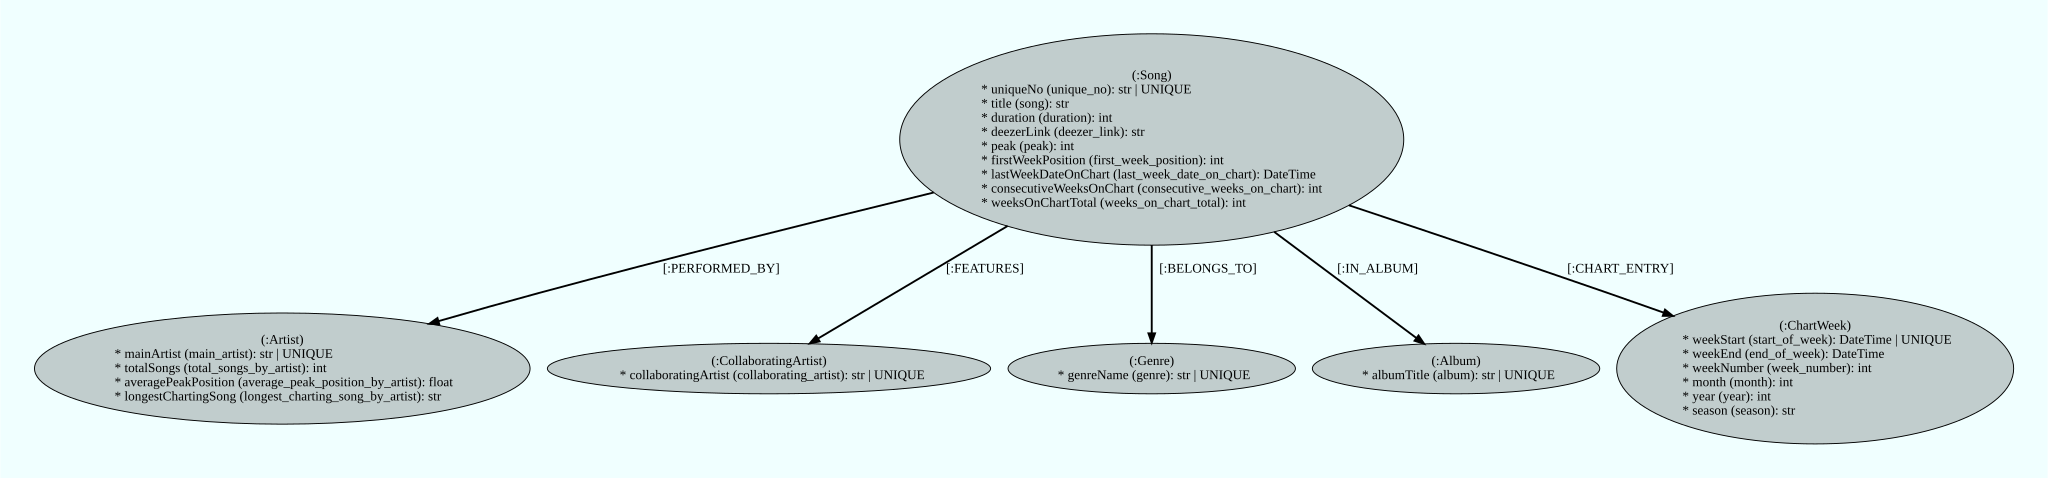

In [237]:
gdm.current_model.visualize()

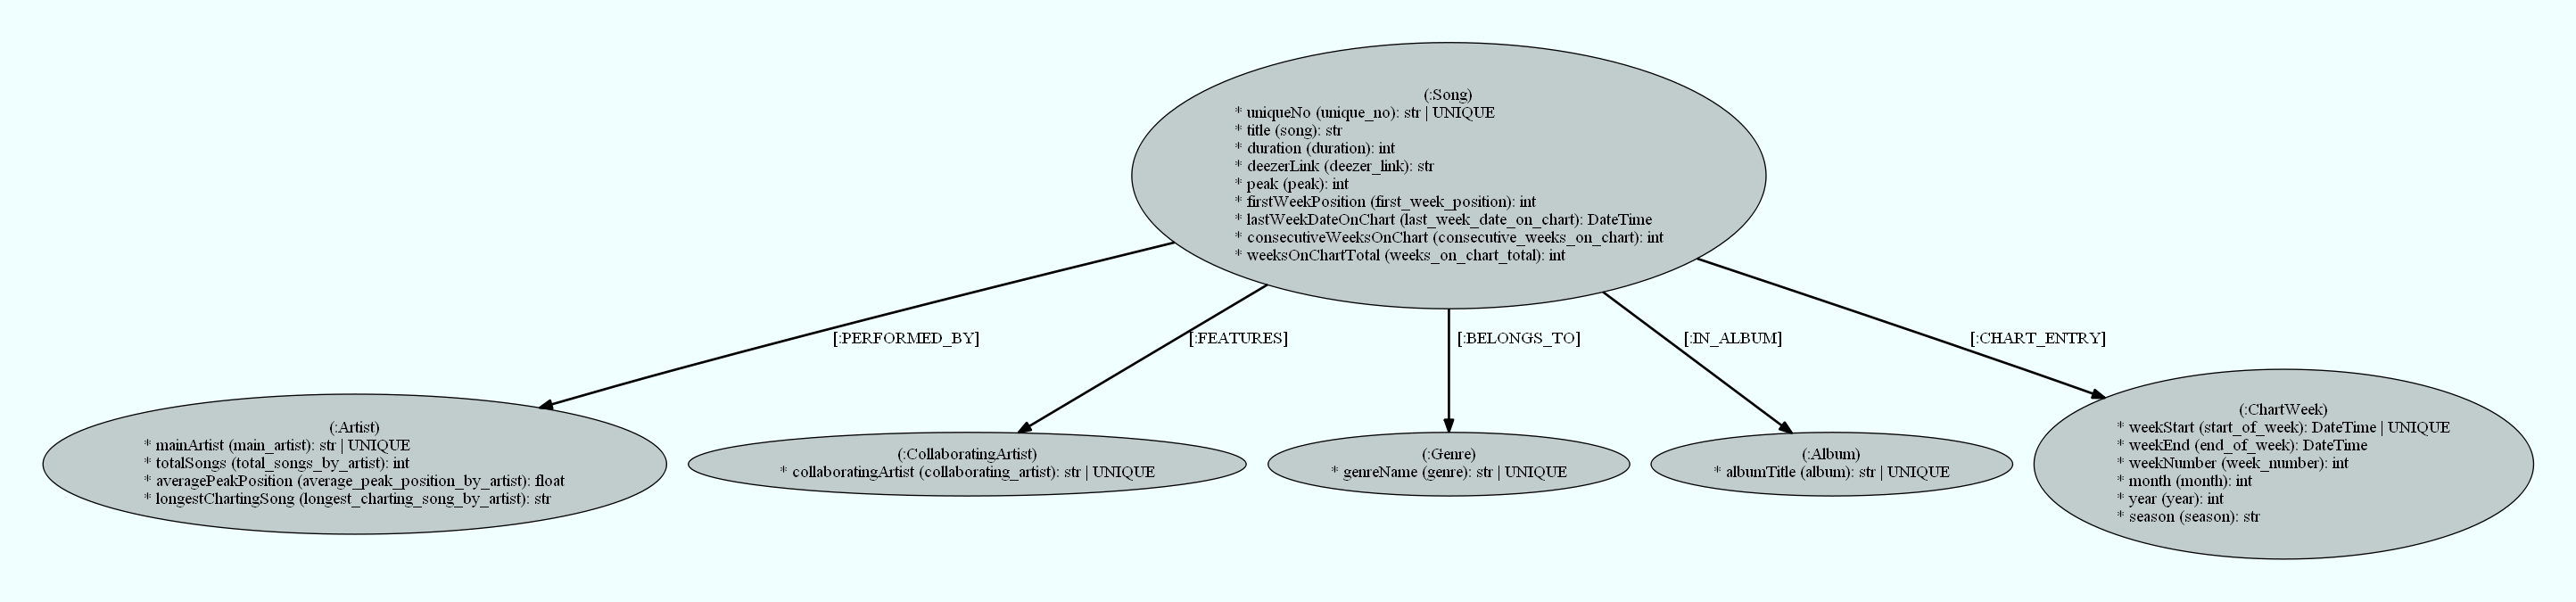

In [238]:
from IPython.display import Image, display
gdm.current_model.visualize().render('images/graph_model', format='png')
# Load and display the image with a specific width
img = Image('images/graph_model.png', width=1200)  # Adjust the width as needed
display(img)

In [239]:
# instantiate ingestion generator
gen = PyIngestConfigGenerator(data_model=gdm.current_model, 
                 username=os.getenv("NEO4J_USERNAME"), 
                 password=os.getenv("NEO4J_PASSWORD"), 
                 uri=os.getenv("NEO4J_URI"), 
                 database=os.getenv("NEO4J_DATABASE"), 
                 file_directory="data/neo4j/", source_name="graph_df.csv")


In [240]:
# create ingestion YAML
pyingest_yaml = gen.generate_config_string()

In [241]:

#PyIngest(config=pyingest_yaml, verbose=False)

In [242]:
# save yaml file
gen.generate_config_yaml(file_name="uktop100chart.yaml")

In [243]:


# Test Connection to Neo4j
test_database_connection(credentials={"username": os.getenv("NEO4J_USERNAME"), 
                                      "password": os.getenv("NEO4J_PASSWORD"), 
                                      "uri": os.getenv("NEO4J_URI")})

{'valid': True, 'message': 'Connection and Auth Verified!'}

In [244]:
# Use generated PyIngest yaml config to ingest our data into our Neo4j instance
PyIngest(config=pyingest_yaml, dataframe=graph_df)

ClientError: {code: Neo.ClientError.Transaction.TransactionHookFailed} {message: You have exceeded the logical size limit of 400000 relationships in your database (attempt to add 99 relationships would reach 400034 relationships). Please consider upgrading to the next tier.}

**Please note**


Limitation of the generated graph model: There is a limit of 400000 relationships for Free Neo4j Aura, thus no more node or relation could be created.

#### **Testing the graph database**

**Query 1**

This Cypher query matches nodes where node is any of the following select Song, Artist, Album, Genre, ChartWeek. By default, it is limited to  1000 nodes.

```cypher

MATCH (n)
WHERE n:Song OR n:Artist OR n:Album OR n:Genre OR n:ChartWeek
OPTIONAL MATCH (n)-[r]->(m)
RETURN n, r, m

```

![title](images/cypher_query_1.png)


**Query 2**

Select songs by Ed Sheeran, limit graph nodes to 25
```cypher

MATCH (a:Artist {mainArtist: "ed sheeran"})<-[:PERFORMED_BY]-(s:Song)
OPTIONAL MATCH (s)-[r]-(a)
RETURN s, r, a
LIMIT 25

```

![title](images/cypher_query_2.png)


**Query 3**

Select Rock songs that entered the chart, limit graph nodes to 10 nodes
```cypher

MATCH (s:Song)-[:BELONGS_TO]->(g:Genre)
MATCH (s:Song)-[:CHART_ENTRY]->(cw:ChartWeek)
WHERE g.genreName = "Rock"
RETURN s
LIMIT 10

```

![title](images/cypher_query_3.png)


In [246]:
knowledge_graph = Neo4jGraph(
    url=os.getenv("NEO4J_URI"), 
    username=os.getenv("NEO4J_USERNAME"), 
    password=os.getenv("NEO4J_PASSWORD"), 
    database=os.getenv("NEO4J_DATABASE")
)

knowledge_graph.refresh_schema()
print(textwrap.fill(knowledge_graph.schema, 60))

schema=knowledge_graph.schema

Node properties: Song {uniqueNo: INTEGER, title: STRING,
duration: INTEGER, deezerLink: STRING, peak: INTEGER,
firstWeekPosition: INTEGER, lastWeekDateOnChart: DATE_TIME,
consecutiveWeeksOnChart: INTEGER, weeksOnChartTotal:
INTEGER} Artist {mainArtist: STRING, totalSongs: INTEGER,
averagePeakPosition: FLOAT, longestChartingSong: STRING}
CollaboratingArtist {collaboratingArtist: STRING} Genre
{genreName: STRING} Album {albumTitle: STRING} ChartWeek
{weekStart: DATE_TIME, weekEnd: DATE_TIME, weekNumber:
INTEGER, month: INTEGER, year: INTEGER, season: STRING}
Relationship properties:  The relationships:
(:Song)-[:PERFORMED_BY]->(:Artist)
(:Song)-[:FEATURES]->(:CollaboratingArtist)
(:Song)-[:BELONGS_TO]->(:Genre)
(:Song)-[:IN_ALBUM]->(:Album)
(:Song)-[:CHART_ENTRY]->(:ChartWeek)


In [247]:
from langchain.prompts.prompt import PromptTemplate
from langchain.chains import GraphCypherQAChain
from langchain_ollama import ChatOllama

In [248]:
# Initialize llm
llm = ChatOllama(
    model="gemma3:12b",
    temperature=0.1,
    )

In [250]:

prompt_template = """
You are a Cypher query generator for a Neo4j graph database.

Here are this list of Nodes
1. (:Song)                  
2. (:Artist)
3. (:CollaboratingArtist)   
4. (:Genre)
5. (:Album)                 
6. (:ChartWeek) 

Here are this list of Relationships
(:Song)-[:PERFORMED_BY]->(:Artist)            
(:Song)-[:FEATURES]->(:CollaboratingArtist)   
(:Song)-[:BELONGS_TO]->(:Genre)               
(:Song)-[:IN_ALBUM]->(:Album)                 
(:Song)-[:CHART_ENTRY]->(:ChartWeek) 

## Step 1: Understand the task
Your goal is to generate a Cypher query that answers the user's question using the provided graph schema.

## Step 2: Schema
Here is the schema of the graph database:
{schema}

## Step 3: Instructions
- Only use **node labels**, **relationship types**, and **property keys** that are explicitly mentioned in the schema.
- Do not assume any property exists unless it is listed in the schema.
- If a node or property is marked as "unknown" or "None", do not include it in the query.
- Do not include comments in the Cypher query.
- Return only the Cypher query, nothing else.

## Step 4: Examples

**Q: Which songs had a peak position of number 1 in 2021?**  
MATCH (s:Song)-[:CHART_ENTRY]->(cw:ChartWeek)
WHERE s.peak = 1 AND cw.year = 2021
RETURN s

**Q: List songs released by Ed Sheeran**  
MATCH (s:Song)-[:PERFORMED_BY]->(a:Artist)
WHERE a.mainArtist = "ed sheeran"
RETURN s.title AS SongTitle

**Q: What are the songs released by Elvis Presley that peaked at number 1?**  
MATCH (s:Song)-[:PERFORMED_BY]->(a:Artist)  
MATCH (s)-[:IN_ALBUM]->(al:Album)  
MATCH (s)-[:BELONGS_TO]->(g:Genre)  
WHERE s.peak = 1 AND a.mainArtist =  "elvis presley"
RETURN s.title AS SongTitle, al.albumTitle AS Album, g.genreName AS Genre

**Q: How does Ed Sheeran compare to 50 Cent on the chart?**  
MATCH (s:Song)-[:PERFORMED_BY]->(a:Artist)
MATCH (s:Song)-[:CHART_ENTRY]->(cw:ChartWeek)  
WHERE a.mainArtist IN ["ed sheeran", "50 cent"]  
RETURN a.mainArtist AS Artist, s.title AS SongTitle, s.peak AS Peak, cw.year AS Year  
ORDER BY Artist, Peak ASC

## Step 5: User Question
{question}
"""

In [251]:
cypher_prompt = PromptTemplate(
    input_variables=["schema","question"], 
    template=prompt_template
)

cypherChain = GraphCypherQAChain.from_llm(
    llm = llm,
    graph=knowledge_graph,
    verbose=True,
    cypher_prompt=cypher_prompt,
    allow_dangerous_requests=True,
    top_k=10 # this can be adjusted also
)



In [258]:
cypherChain.invoke("""How many songs are in the chart in 2000?""")



> Entering new GraphCypherQAChain chain...
Generated Cypher:
cypher
MATCH (s:Song)-[:CHART_ENTRY]->(cw:ChartWeek)
WHERE cw.year = 2000
RETURN count(s)



[#D1B8]  _: <CONNECTION> error: Failed to read from defunct connection ResolvedIPv4Address(('35.205.213.74', 7687)) (ResolvedIPv4Address(('35.205.213.74', 7687))): OSError('No data')
Unable to retrieve routing information
Transaction failed and will be retried in 0.9514854222217677s (Unable to retrieve routing information)
[#D143]  _: <CONNECTION> error: Failed to read from defunct connection IPv4Address(('si-e1495fec-c433.production-orch-0055.neo4j.io', 7687)) (ResolvedIPv4Address(('35.205.213.74', 7687))): OSError('No data')
Transaction failed and will be retried in 1.9727395176247273s (Failed to read from defunct connection IPv4Address(('si-e1495fec-c433.production-orch-0055.neo4j.io', 7687)) (ResolvedIPv4Address(('35.205.213.74', 7687))))


Full Context:
[{'count(s)': 5300}]

> Finished chain.


{'query': 'How many songs are in the chart in 2000?',
 'result': 'There are 5300 songs in the chart in 2000.'}

In [253]:
cypherChain.invoke(""" what is the most genre in 2021?""")



> Entering new GraphCypherQAChain chain...
Generated Cypher:
cypher
MATCH (s:Song)-[:BELONGS_TO]->(g:Genre)
MATCH (s:Song)-[:CHART_ENTRY]->(cw:ChartWeek)
WHERE cw.year = 2021
RETURN g.genreName AS Genre
ORDER BY Genre
LIMIT 1

Full Context:
[{'Genre': 'Alternative'}]

> Finished chain.


{'query': ' what is the most genre in 2021?', 'result': 'Alternative.'}

In [254]:
cypherChain.invoke("""please list the songs released by elvis presley""")



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (s:Song)-[:PERFORMED_BY]->(a:Artist)
WHERE a.mainArtist = "elvis presley"
RETURN s
Full Context:
[{'s': {'uniqueNo': 8801615898, 'duration': 194, 'lastWeekDateOnChart': neo4j.time.DateTime(2007, 9, 9, 0, 0, 0, 0, tzinfo=<UTC>), 'weeksOnChartTotal': 21, 'peak': 2, 'title': 'suspicious minds', 'consecutiveWeeksOnChart': 17, 'firstWeekPosition': 39, 'deezerLink': 'https://www.deezer.com/track/1055776'}}, {'s': {'uniqueNo': 5981099870, 'duration': 168, 'lastWeekDateOnChart': neo4j.time.DateTime(1970, 5, 3, 0, 0, 0, 0, tzinfo=<UTC>), 'weeksOnChartTotal': 11, 'peak': 8, 'title': "don't cry daddy", 'consecutiveWeeksOnChart': 10, 'firstWeekPosition': 30, 'deezerLink': 'https://www.deezer.com/track/1048270562'}}, {'s': {'uniqueNo': 4762117490, 'duration': 194, 'lastWeekDateOnChart': neo4j.time.DateTime(1970, 8, 2, 0, 0, 0, 0, tzinfo=<UTC>), 'weeksOnChartTotal': 12, 'peak': 21, 'title': 'kentucky rain', 'consecutiveWeeksOnChart

{'query': 'please list the songs released by elvis presley',
 'result': "The songs are: suspicious minds, don't cry daddy, kentucky rain, the wonder of you, i've lost you, you don't have to say you love me, the goes my everything, rags to riches, heartbak hotel and hound dog, i'm leavin'."}

In [151]:
#os.system('jupyter nbconvert --to html Dacoe_Challenge.ipynb')

0